# ICML 16_Runs Experiment Analysis

Comprehensive analysis of grokking dynamics across 16 architectural/optimizer configurations with 6 weight decay values (96 total experiments).

## Experiment Factors
- **Modulus**: 97 vs 113
- **Attention**: Softmax vs ReLU
- **LayerNorm**: On vs Off
- **Optimizer**: Adam vs Muon
- **Weight Decay**: 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0


In [45]:
import os
import sys
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Results directory
RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)

print(f"Results directory: {RESULTS_DIR.absolute()}")
print(f"Figures directory: {FIGURES_DIR.absolute()}")


Results directory: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/ICML_Submission/16_Runs/analysis/../results
Figures directory: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/ICML_Submission/16_Runs/analysis/figures


## 1. Load All Experiment Results


In [46]:
def load_experiment(exp_dir):
    """Load all data from an experiment directory."""
    exp_dir = Path(exp_dir)
    data = {'path': str(exp_dir)}
    
    # Load config
    config_path = exp_dir / 'config.json'
    if config_path.exists():
        with open(config_path) as f:
            data['config'] = json.load(f)
    
    # Load training history
    history_path = exp_dir / 'training_history.json'
    if history_path.exists():
        with open(history_path) as f:
            data['history'] = json.load(f)
    
    # Load AGOP metrics
    agop_path = exp_dir / 'agop_metrics.h5'
    if agop_path.exists():
        data['agop'] = {}
        with h5py.File(agop_path, 'r') as f:
            for key in f.keys():
                data['agop'][key] = f[key][:]
    
    # Load Lazy-Rich metrics
    lr_path = exp_dir / 'lazy_rich_metrics.h5'
    if lr_path.exists():
        data['lazy_rich'] = {}
        with h5py.File(lr_path, 'r') as f:
            for key in f.keys():
                data['lazy_rich'][key] = f[key][:]
    
    return data


def parse_experiment_name(exp_name):
    """Parse experiment name to extract configuration."""
    # Format: p{mod}_{attn}_{ln}_{opt}/wd{wd}_seed{seed}
    parts = exp_name.split('/')
    base_config = parts[0]
    wd_part = parts[1] if len(parts) > 1 else ''
    
    # Parse base config
    tokens = base_config.split('_')
    config = {
        'modulus': int(tokens[0][1:]),  # p97 -> 97
        'attention': tokens[1],
        'layernorm': tokens[2] == 'ln',
        'optimizer': tokens[3],
    }
    
    # Parse weight decay
    if wd_part.startswith('wd'):
        config['weight_decay'] = float(wd_part.split('_')[0][2:])
    
    return config


# Load all experiments
experiments = []

for base_dir in sorted(RESULTS_DIR.glob('p*_*_*_*')):
    if base_dir.is_dir():
        for wd_dir in sorted(base_dir.glob('wd*_seed*')):
            if wd_dir.is_dir():
                exp_name = f"{base_dir.name}/{wd_dir.name}"
                try:
                    data = load_experiment(wd_dir)
                    data['name'] = exp_name
                    data['parsed'] = parse_experiment_name(exp_name)
                    experiments.append(data)
                except Exception as e:
                    print(f"Error loading {exp_name}: {e}")

print(f"Loaded {len(experiments)} experiments")


Loaded 96 experiments


## 2. Summary Statistics


In [47]:
def detect_grokking(history, threshold=0.95):
    """Detect if/when grokking occurred."""
    test_accs = history.get('test_acc', [])
    epochs = history.get('epoch', [])
    
    for i, acc in enumerate(test_accs):
        if acc >= threshold:
            return True, epochs[i]
    return False, None


# Build summary DataFrame
summary_data = []

for exp in experiments:
    if 'history' not in exp:
        continue
    
    parsed = exp['parsed']
    history = exp['history']
    grokked, grok_epoch = detect_grokking(history)
    
    row = {
        'name': exp['name'],
        'modulus': parsed['modulus'],
        'attention': parsed['attention'],
        'layernorm': parsed['layernorm'],
        'optimizer': parsed['optimizer'],
        'weight_decay': parsed['weight_decay'],
        'final_train_acc': history['train_acc'][-1] if history['train_acc'] else None,
        'final_test_acc': history['test_acc'][-1] if history['test_acc'] else None,
        'grokked': grokked,
        'grok_epoch': grok_epoch,
    }
    
    # Add final AGOP metrics
    if 'agop' in exp:
        for key in ['agop_eigengap', 'agop_variation_collapse_ratio', 'agop_trace']:
            if key in exp['agop'] and len(exp['agop'][key]) > 0:
                row[f'final_{key}'] = exp['agop'][key][-1]
    
    # Add final NTK distance
    if 'lazy_rich' in exp and 'ntk_distance' in exp['lazy_rich']:
        if len(exp['lazy_rich']['ntk_distance']) > 0:
            row['final_ntk_distance'] = exp['lazy_rich']['ntk_distance'][-1]
            row['max_ntk_distance'] = max(exp['lazy_rich']['ntk_distance'])
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(f"Summary DataFrame shape: {summary_df.shape}")
summary_df.head(10)


Summary DataFrame shape: (96, 13)


,name,modulus,attention,layernorm,optimizer,weight_decay,final_train_acc,final_test_acc,grokked,grok_epoch,final_agop_eigengap,final_agop_variation_collapse_ratio,final_agop_trace
0,p113_relu_ln_adam/wd0.0001_seed42,113,relu,True,adam,0.00010,1.000000,1.000000,True,13000.0,1.213884e+00,0.084444,1.315716e+02
1,p113_relu_ln_adam/wd0.001_seed42,113,relu,True,adam,0.00100,1.000000,1.000000,True,4200.0,3.375881e-01,0.087551,4.951004e+01
2,p113_relu_ln_adam/wd0.01_seed42,113,relu,True,adam,0.01000,1.000000,1.000000,True,600.0,1.236012e+00,0.125644,4.570080e+01
3,p113_relu_ln_adam/wd0.1_seed42,113,relu,True,adam,0.10000,0.016604,0.011746,False,NaN,6.040321e+01,1.000001,6.040319e+01
4,p113_relu_ln_adam/wd1.0_seed42,113,relu,True,adam,1.00000,0.010652,0.007048,False,NaN,1.465934e-19,0.000000,4.301548e-19
5,p113_relu_ln_adam/wd1e-05_seed42,113,relu,True,adam,0.00001,1.000000,1.000000,True,26100.0,4.865524e+00,0.092847,6.683866e+02
6,p113_relu_ln_muon/wd0.0001_seed42,113,relu,True,muon,0.00010,1.000000,0.005638,False,NaN,8.288043e+01,0.024777,4.331031e+04
7,p113_relu_ln_muon/wd0.001_seed42,113,relu,True,muon,0.00100,1.000000,0.004542,False,NaN,7.736572e+01,0.023623,4.330209e+04
8,p113_relu_ln_muon/wd0.01_seed42,113,relu,True,muon,0.01000,1.000000,0.004229,False,NaN,3.139355e+01,0.024310,3.992435e+04
9,p113_relu_ln_muon/wd0.1_seed42,113,relu,True,muon,0.10000,1.000000,0.001253,False,NaN,3.545532e+00,0.027301,6.187993e+02


In [48]:
# Grokking rate by configuration
print("="*60)
print("Grokking Rate by Factor")
print("="*60)

for factor in ['modulus', 'attention', 'layernorm', 'optimizer']:
    print(f"\n{factor.upper()}:")
    grok_rates = summary_df.groupby(factor)['grokked'].mean()
    for val, rate in grok_rates.items():
        n_grok = summary_df[summary_df[factor] == val]['grokked'].sum()
        n_total = (summary_df[factor] == val).sum()
        print(f"  {val}: {rate:.1%} ({n_grok}/{n_total})")


Grokking Rate by Factor

MODULUS:
  97: 43.8% (21/48)
  113: 41.7% (20/48)

ATTENTION:
  relu: 31.2% (15/48)
  softmax: 54.2% (26/48)

LAYERNORM:
  False: 25.0% (12/48)
  True: 60.4% (29/48)

OPTIMIZER:
  adam: 60.4% (29/48)
  muon: 25.0% (12/48)


In [49]:
# Grokking rate by weight decay
print("\nGROKKING RATE BY WEIGHT DECAY:")
wd_grok = summary_df.groupby('weight_decay').agg({
    'grokked': ['sum', 'count', 'mean'],
    'grok_epoch': 'mean'
})
wd_grok.columns = ['n_grokked', 'n_total', 'grok_rate', 'mean_grok_epoch']
print(wd_grok)



GROKKING RATE BY WEIGHT DECAY:
              n_grokked  n_total  grok_rate  mean_grok_epoch
weight_decay                                                
0.00001              10       16     0.6250          11380.0
0.00010              10       16     0.6250           3710.0
0.00100              10       16     0.6250           1550.0
0.01000               6       16     0.3750            700.0
0.10000               3       16     0.1875           1000.0
1.00000               2       16     0.1250            900.0


## 3. Training Curves Comparison


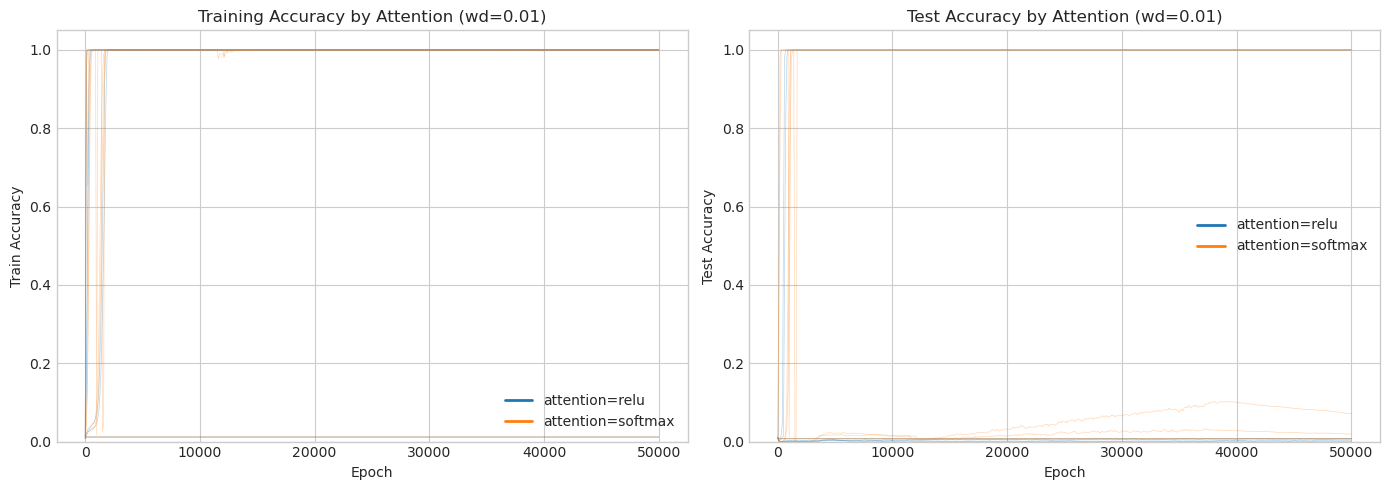

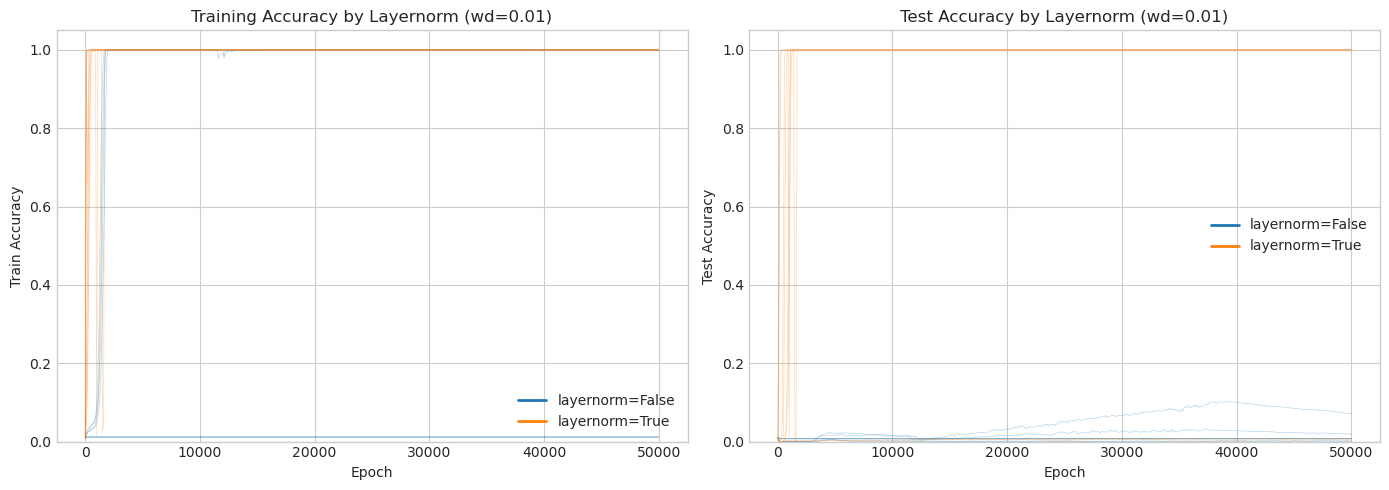

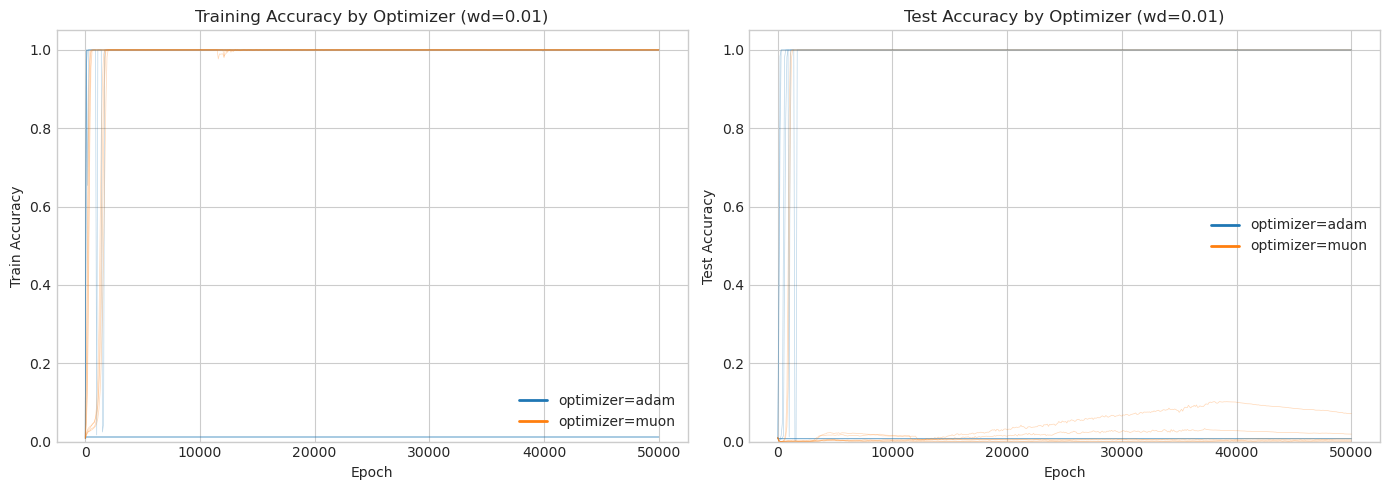

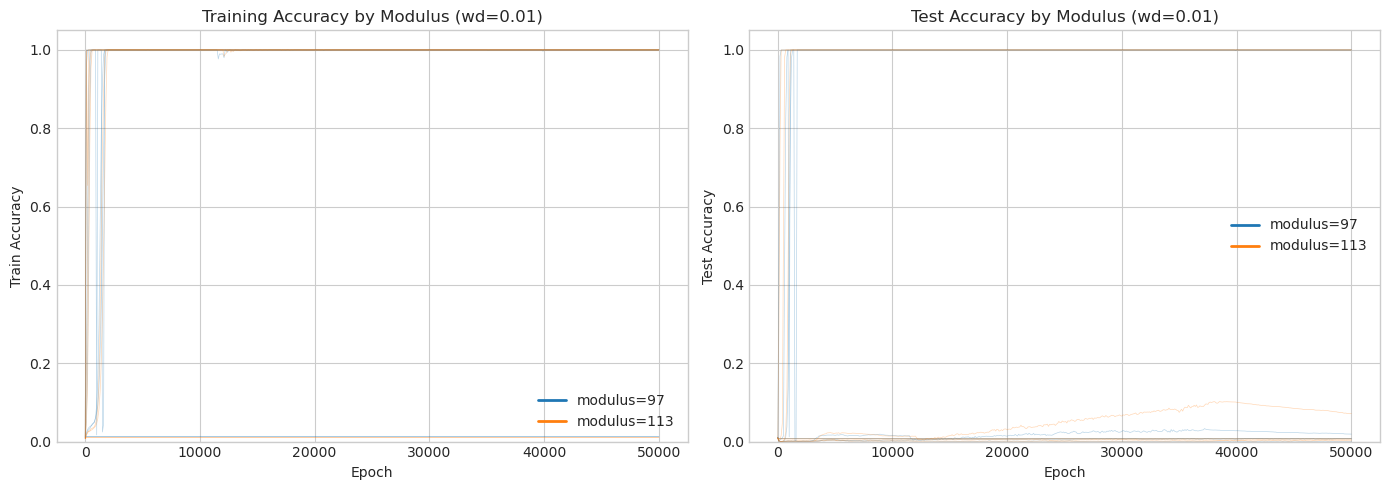

In [50]:
def plot_training_curves_by_factor(experiments, factor, weight_decay=0.01, figsize=(14, 5)):
    """Plot training curves grouped by a specific factor."""
    
    # Filter experiments
    filtered = [e for e in experiments 
                if 'history' in e and 
                abs(e['parsed']['weight_decay'] - weight_decay) < 1e-10]
    
    if not filtered:
        print(f"No experiments found with weight_decay={weight_decay}")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Group by factor value
    groups = defaultdict(list)
    for exp in filtered:
        val = exp['parsed'][factor]
        groups[val].append(exp)
    
    colors = plt.cm.tab10.colors
    
    for idx, (val, exps) in enumerate(sorted(groups.items())):
        for exp in exps:
            history = exp['history']
            epochs = history['epoch']
            
            # Train accuracy
            axes[0].plot(epochs, history['train_acc'], 
                        color=colors[idx], alpha=0.3, linewidth=0.5)
            # Test accuracy
            axes[1].plot(epochs, history['test_acc'], 
                        color=colors[idx], alpha=0.3, linewidth=0.5)
        
        # Add legend entry
        axes[0].plot([], [], color=colors[idx], label=f'{factor}={val}', linewidth=2)
        axes[1].plot([], [], color=colors[idx], label=f'{factor}={val}', linewidth=2)
    
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Train Accuracy')
    axes[0].set_title(f'Training Accuracy by {factor.title()} (wd={weight_decay})')
    axes[0].legend()
    axes[0].set_ylim([0, 1.05])
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Test Accuracy')
    axes[1].set_title(f'Test Accuracy by {factor.title()} (wd={weight_decay})')
    axes[1].legend()
    axes[1].set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig

# Plot by each factor
for factor in ['attention', 'layernorm', 'optimizer', 'modulus']:
    fig = plot_training_curves_by_factor(experiments, factor, weight_decay=0.01)
    if fig:
        fig.savefig(FIGURES_DIR / f'training_curves_by_{factor}.png', dpi=150, bbox_inches='tight')
        plt.show()


## 4. AGOP Metrics Analysis


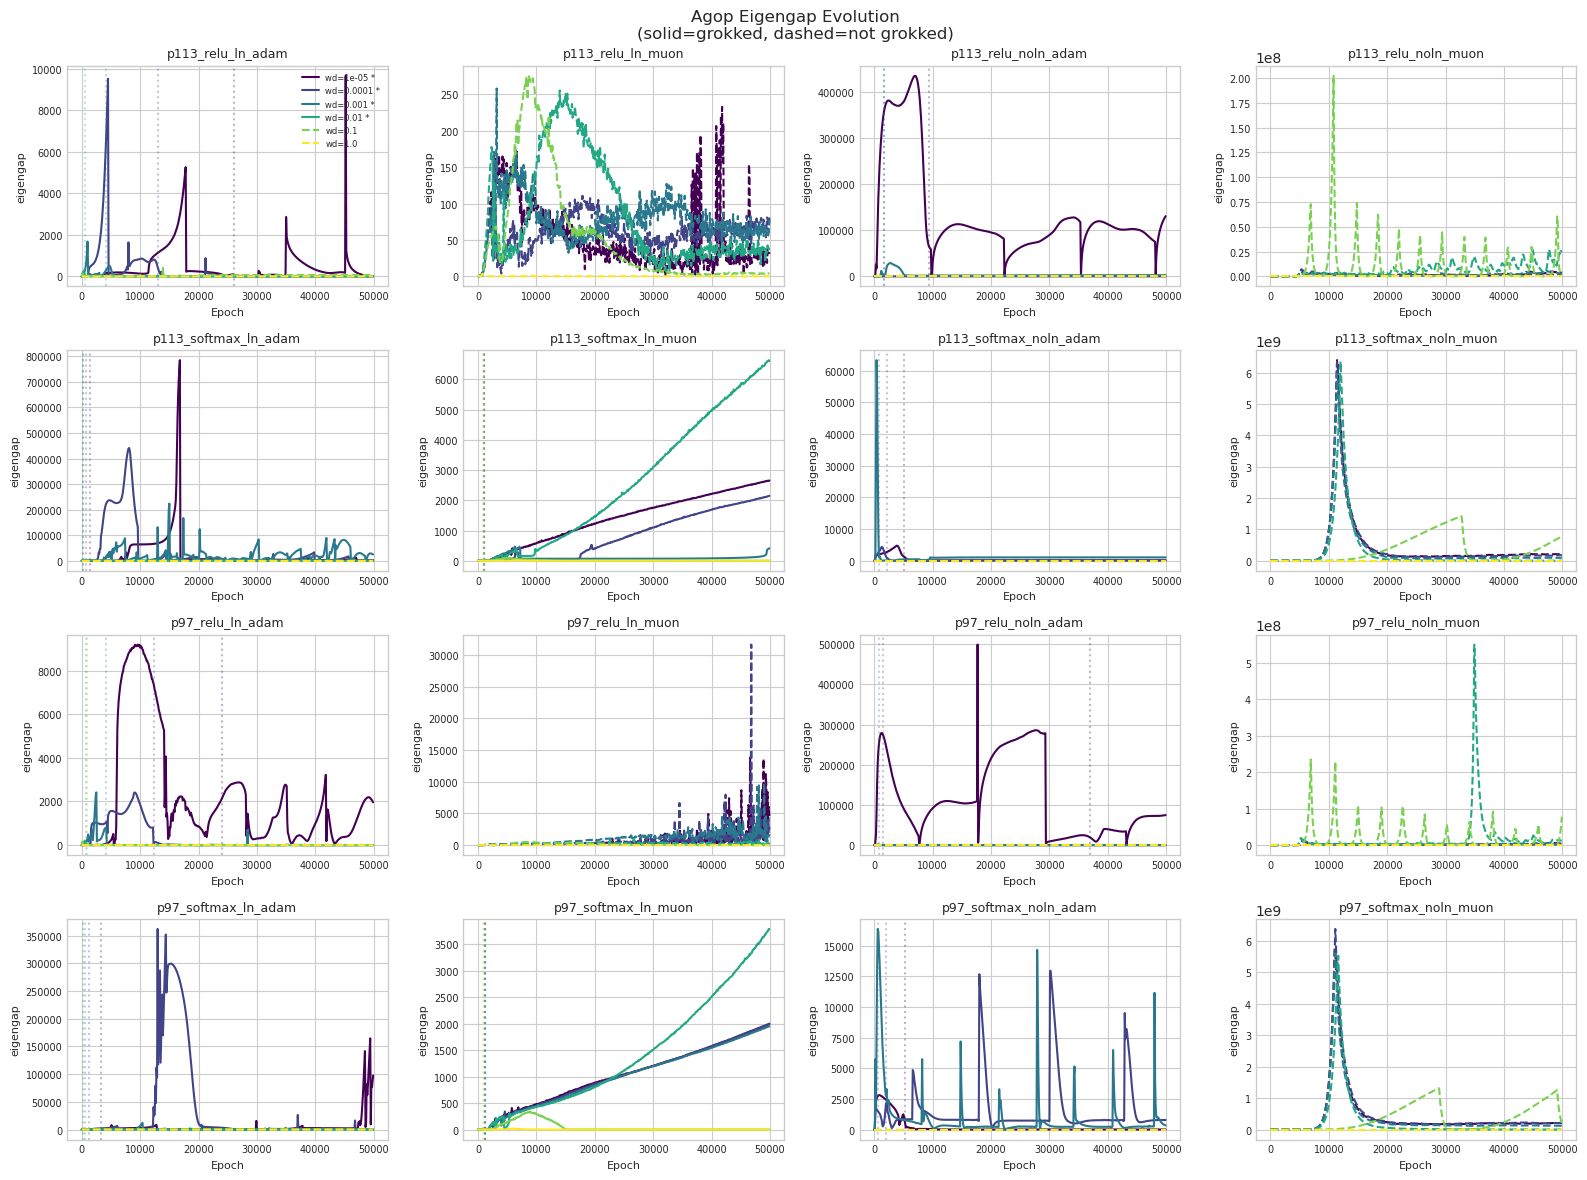

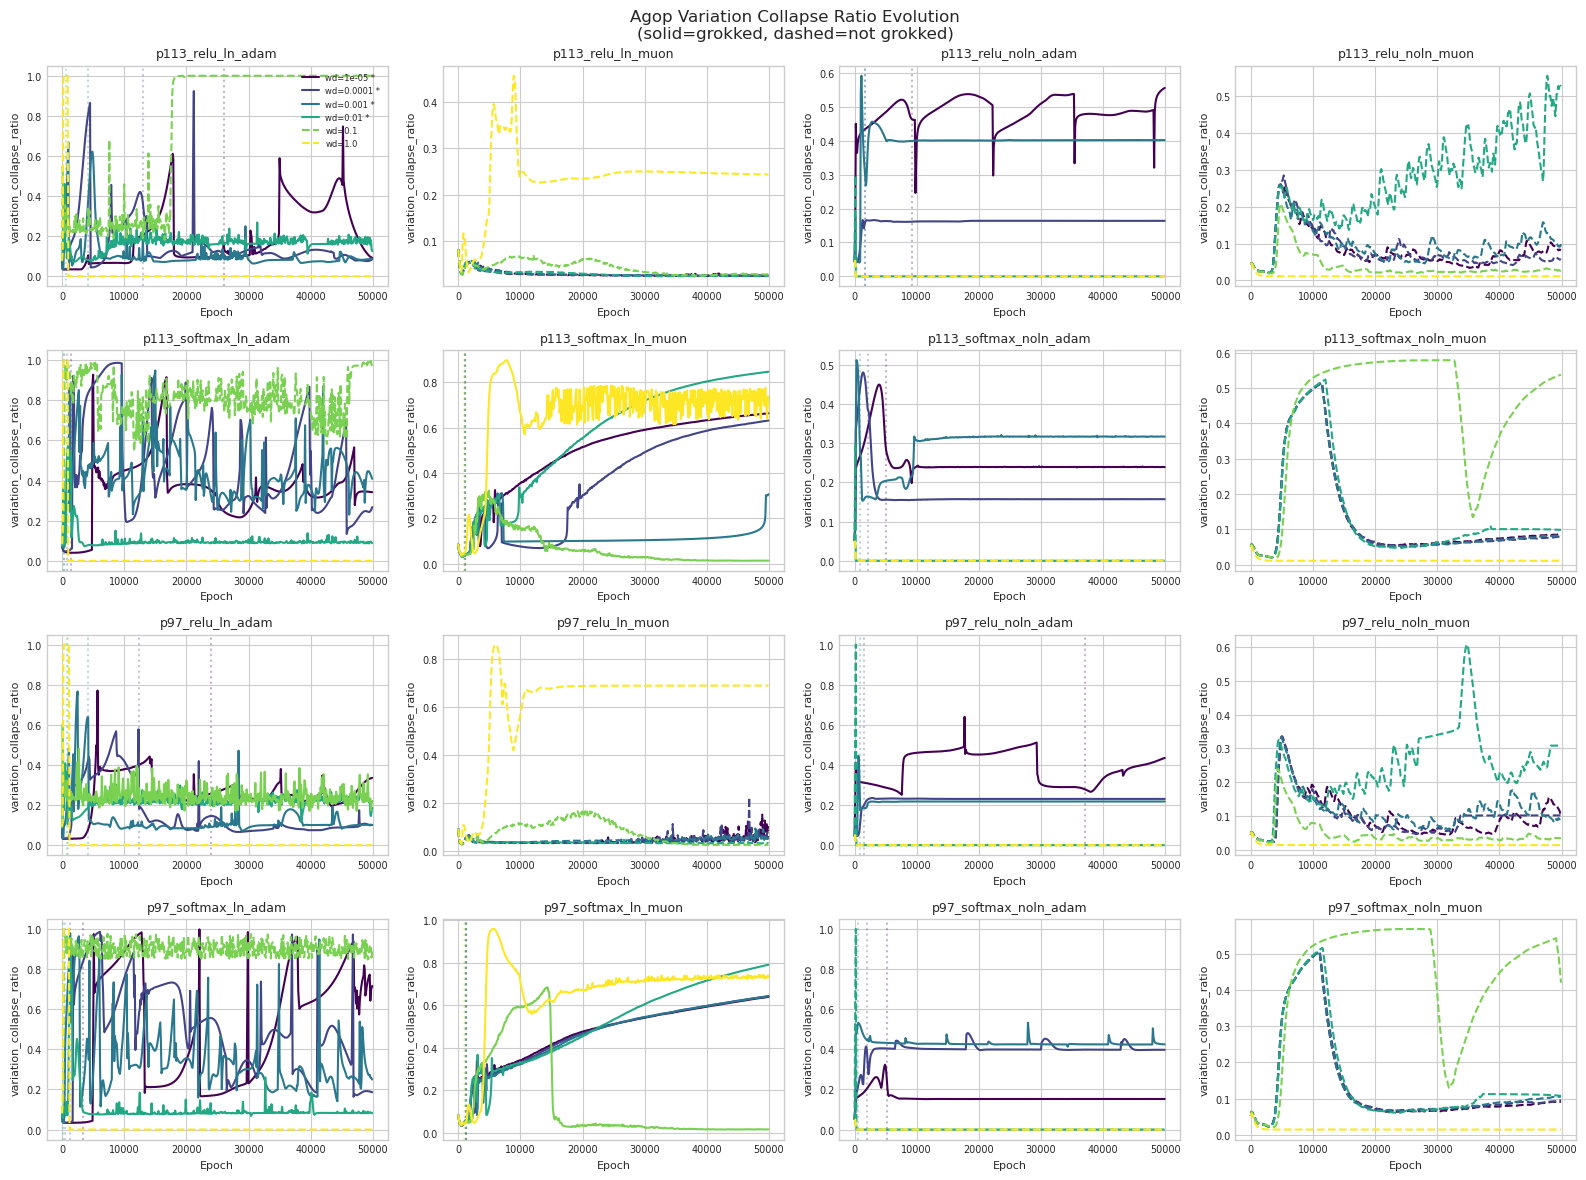

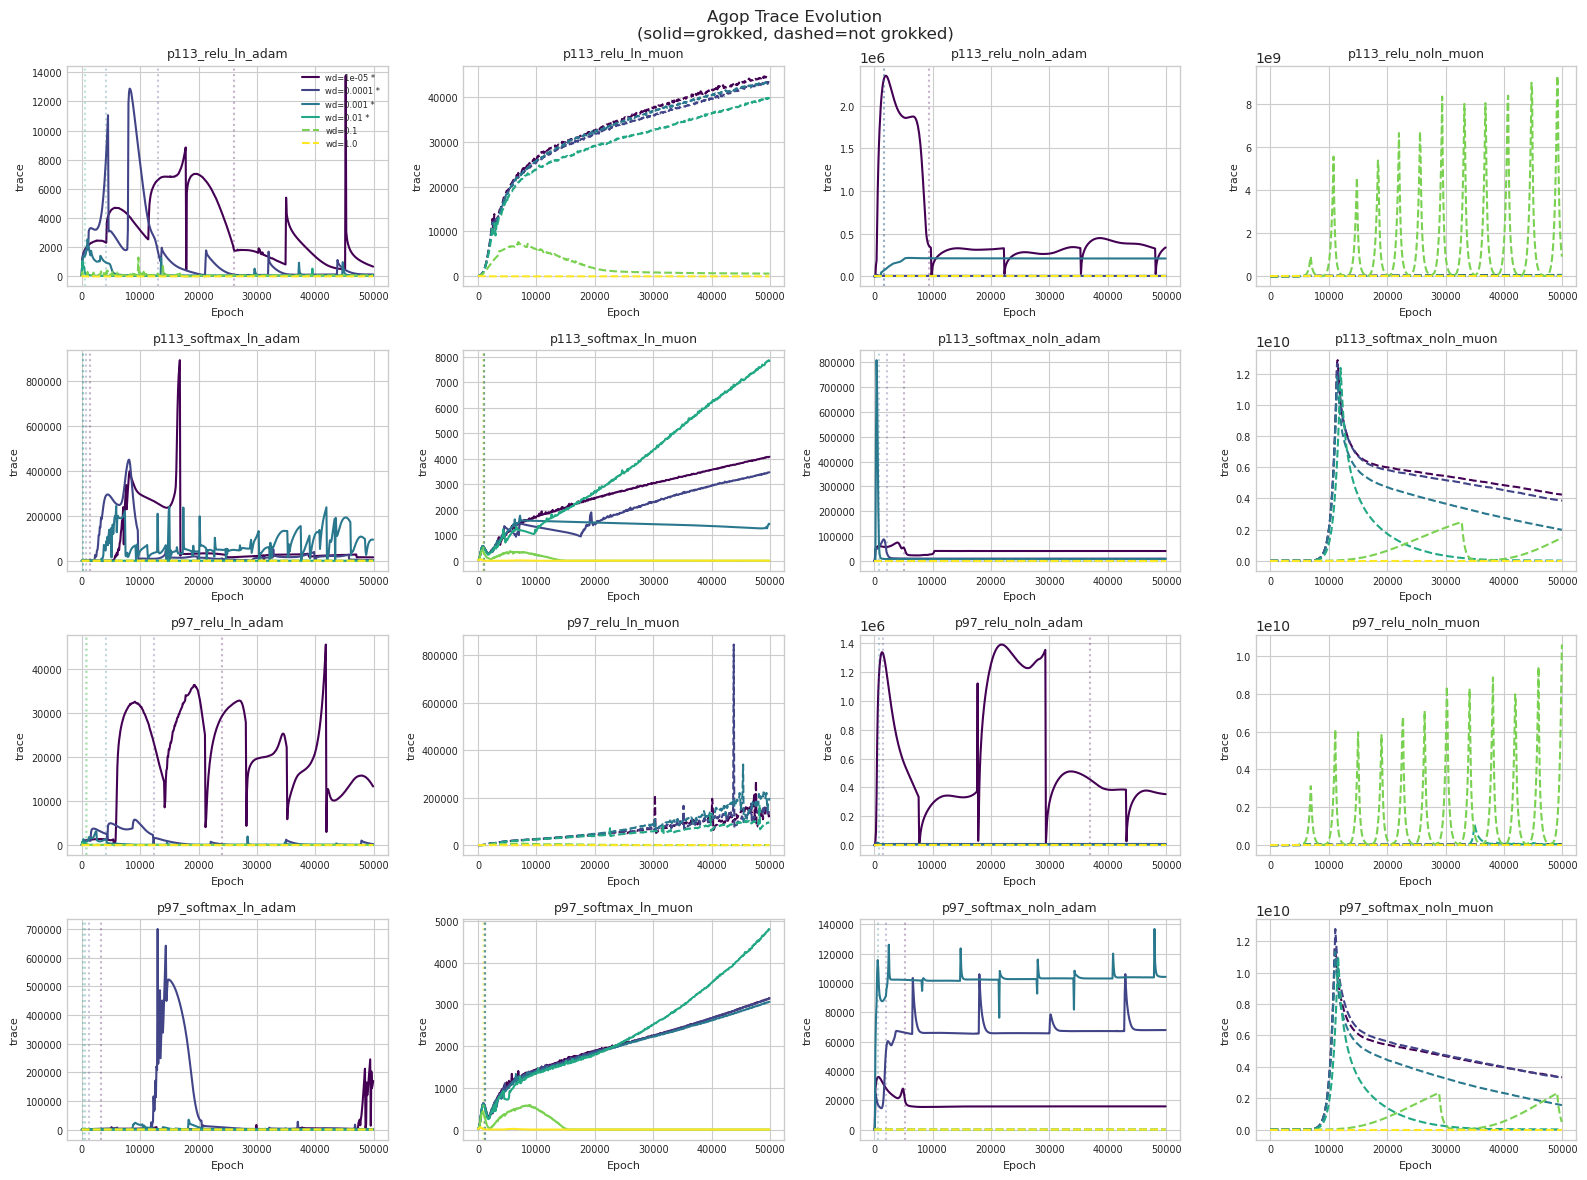

In [51]:
def plot_agop_evolution(experiments, metric='agop_eigengap', n_cols=4, figsize=(16, 12)):
    """Plot AGOP metric evolution for all experiments."""
    
    # Filter experiments with AGOP data
    filtered = [e for e in experiments if 'agop' in e and metric in e['agop']]
    
    if not filtered:
        print(f"No experiments found with metric {metric}")
        return
    
    # Group by base config
    base_configs = {}
    for exp in filtered:
        p = exp['parsed']
        key = f"p{p['modulus']}_{p['attention']}_{('ln' if p['layernorm'] else 'noln')}_{p['optimizer']}"
        if key not in base_configs:
            base_configs[key] = []
        base_configs[key].append(exp)
    
    n_configs = len(base_configs)
    n_rows = (n_configs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    colors = plt.cm.viridis(np.linspace(0, 1, 6))  # 6 weight decays
    weight_decays = sorted(set(e['parsed']['weight_decay'] for e in filtered))
    wd_to_color = {wd: colors[i] for i, wd in enumerate(weight_decays)}
    
    for idx, (config, exps) in enumerate(sorted(base_configs.items())):
        ax = axes[idx]
        
        for exp in sorted(exps, key=lambda x: x['parsed']['weight_decay']):
            wd = exp['parsed']['weight_decay']
            epochs = exp['agop']['epoch']
            values = exp['agop'][metric]
            
            # Detect grokking
            grokked, grok_ep = detect_grokking(exp['history'])
            linestyle = '-' if grokked else '--'
            
            ax.plot(epochs, values, color=wd_to_color[wd], 
                   linestyle=linestyle, linewidth=1.5, 
                   label=f'wd={wd}' + (' *' if grokked else ''))
            
            if grokked and grok_ep is not None:
                ax.axvline(grok_ep, color=wd_to_color[wd], alpha=0.3, linestyle=':')
        
        ax.set_title(config, fontsize=9)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel(metric.replace('agop_', ''), fontsize=8)
        ax.tick_params(labelsize=7)
        
        if idx == 0:
            ax.legend(fontsize=6, loc='upper right')
    
    # Hide empty subplots
    for idx in range(len(base_configs), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle(f'{metric.replace("_", " ").title()} Evolution\n(solid=grokked, dashed=not grokked)', 
                fontsize=12)
    plt.tight_layout()
    return fig

# Plot key AGOP metrics
for metric in ['agop_eigengap', 'agop_variation_collapse_ratio', 'agop_trace']:
    fig = plot_agop_evolution(experiments, metric)
    if fig:
        fig.savefig(FIGURES_DIR / f'{metric}_evolution.png', dpi=150, bbox_inches='tight')
        plt.show()


## 5. NTK Distance Analysis


In [52]:
def plot_ntk_distance_evolution(experiments, n_cols=4, figsize=(16, 12)):
    """Plot NTK distance evolution for all experiments."""
    
    # Filter experiments with lazy-rich data
    filtered = [e for e in experiments 
                if 'lazy_rich' in e and 'ntk_distance' in e['lazy_rich']]
    
    if not filtered:
        print("No experiments found with NTK distance data")
        return
    
    # Group by base config
    base_configs = {}
    for exp in filtered:
        p = exp['parsed']
        key = f"p{p['modulus']}_{p['attention']}_{('ln' if p['layernorm'] else 'noln')}_{p['optimizer']}"
        if key not in base_configs:
            base_configs[key] = []
        base_configs[key].append(exp)
    
    n_configs = len(base_configs)
    n_rows = (n_configs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    colors = plt.cm.plasma(np.linspace(0, 1, 6))
    weight_decays = sorted(set(e['parsed']['weight_decay'] for e in filtered))
    wd_to_color = {wd: colors[i] for i, wd in enumerate(weight_decays)}
    
    for idx, (config, exps) in enumerate(sorted(base_configs.items())):
        ax = axes[idx]
        
        for exp in sorted(exps, key=lambda x: x['parsed']['weight_decay']):
            wd = exp['parsed']['weight_decay']
            epochs = exp['lazy_rich']['epoch']
            ntk_dist = exp['lazy_rich']['ntk_distance']
            
            grokked, grok_ep = detect_grokking(exp['history'])
            linestyle = '-' if grokked else '--'
            
            ax.semilogy(epochs, ntk_dist, color=wd_to_color[wd],
                       linestyle=linestyle, linewidth=1.5,
                       label=f'wd={wd}' + (' *' if grokked else ''))
            
            if grokked and grok_ep is not None:
                ax.axvline(grok_ep, color=wd_to_color[wd], alpha=0.3, linestyle=':')
        
        ax.set_title(config, fontsize=9)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel('NTK Distance', fontsize=8)
        ax.tick_params(labelsize=7)
        
        if idx == 0:
            ax.legend(fontsize=6, loc='upper left')
    
    for idx in range(len(base_configs), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('NTK Distance Evolution (Lazy-to-Rich Transition)\n(solid=grokked, dashed=not grokked)',
                fontsize=12)
    plt.tight_layout()
    return fig

fig = plot_ntk_distance_evolution(experiments)
if fig:
    fig.savefig(FIGURES_DIR / 'ntk_distance_evolution.png', dpi=150, bbox_inches='tight')
    plt.show()


No experiments found with NTK distance data


## 6. Grokking Heatmap by Configuration


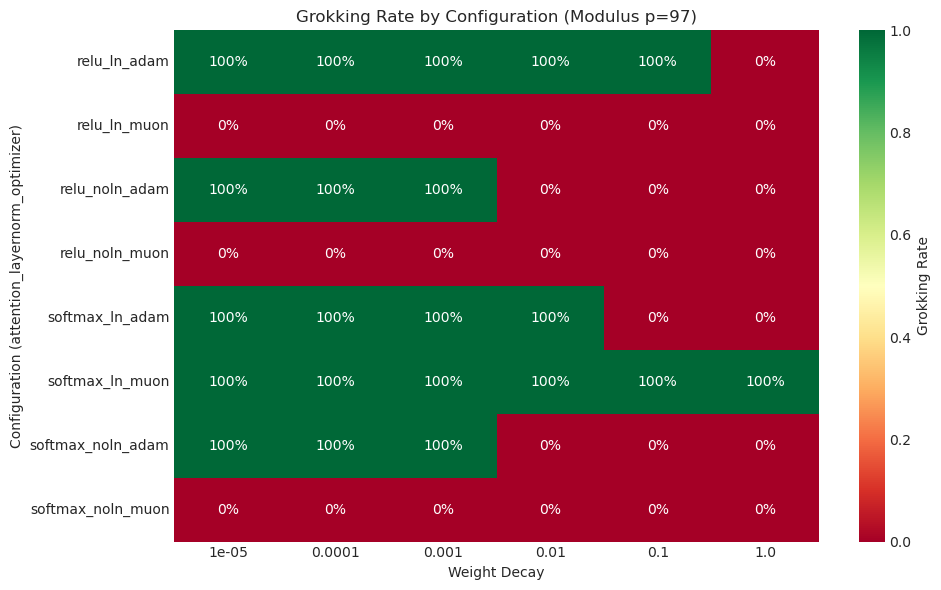

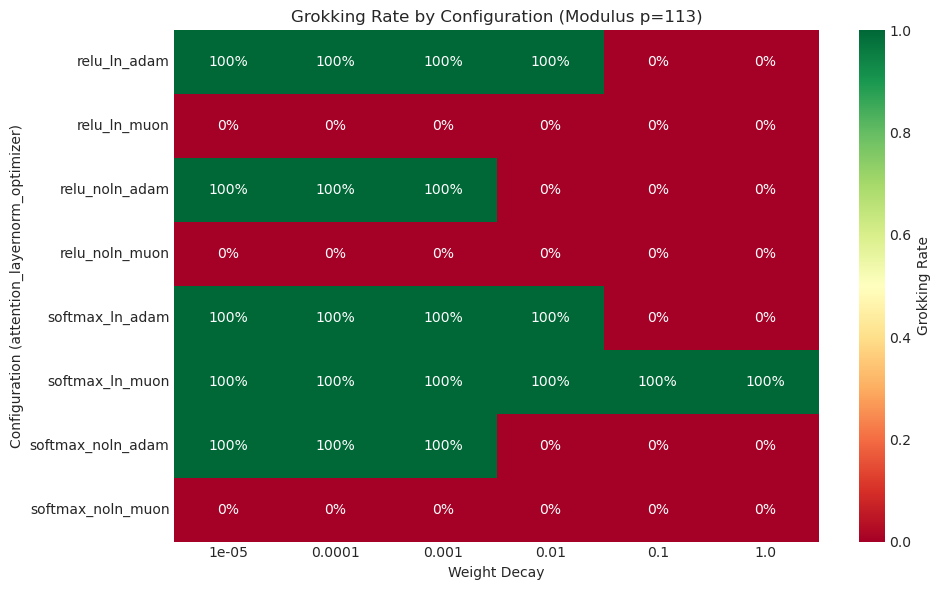

In [53]:
def plot_grokking_heatmap(summary_df):
    """Create heatmap showing grokking success across configurations."""
    
    # Create config string
    df = summary_df.copy()
    df['config'] = (df['attention'] + '_' + 
                   df['layernorm'].map({True: 'ln', False: 'noln'}) + '_' +
                   df['optimizer'])
    
    # Pivot for heatmap
    for modulus in [97, 113]:
        subset = df[df['modulus'] == modulus]
        
        pivot = subset.pivot_table(
            values='grokked',
            index='config',
            columns='weight_decay',
            aggfunc='mean'
        )
        
        plt.figure(figsize=(10, 6))
        sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',
                   vmin=0, vmax=1, cbar_kws={'label': 'Grokking Rate'})
        plt.title(f'Grokking Rate by Configuration (Modulus p={modulus})')
        plt.xlabel('Weight Decay')
        plt.ylabel('Configuration (attention_layernorm_optimizer)')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f'grokking_heatmap_p{modulus}.png', dpi=150, bbox_inches='tight')
        plt.show()

if len(summary_df) > 0:
    plot_grokking_heatmap(summary_df)


## 7. Export Summary Statistics


In [54]:
# Save summary to CSV
if len(summary_df) > 0:
    summary_df.to_csv(FIGURES_DIR / 'experiment_summary.csv', index=False)
    print(f"Saved summary to {FIGURES_DIR / 'experiment_summary.csv'}")
    
    # Print key statistics
    print("\n" + "="*60)
    print("KEY STATISTICS")
    print("="*60)
    print(f"Total experiments: {len(summary_df)}")
    print(f"Grokking rate: {summary_df['grokked'].mean():.1%}")
    grokked_df = summary_df[summary_df['grokked']]
    if len(grokked_df) > 0:
        print(f"Mean grokking epoch (when grokked): {grokked_df['grok_epoch'].mean():.0f}")

print("\nAnalysis complete!")
print(f"Figures saved to: {FIGURES_DIR.absolute()}")


Saved summary to figures/experiment_summary.csv

KEY STATISTICS
Total experiments: 96
Grokking rate: 42.7%
Mean grokking epoch (when grokked): 4278

Analysis complete!
Figures saved to: /net/vast-storage/scratch/vast/lhtsai/mabdel03/files/Classes/9.520/9.520-The-Geometry-of-Grok/New_Explorations/ICML_Submission/16_Runs/analysis/figures


## 8. Research Question Analysis

### Q1: How does optimizer change train/test performance with vs. without LayerNorm?
### Q2: How does optimizer change train/test performance with ReLU vs. Softmax activation?
### Q3: How does optimizer performance change across weight decays in these different conditions?
### Q4: Do these relationships change across datasets (modulus)?


In [55]:
# Color scheme for optimizers (consistent across all figures)
OPTIMIZER_COLORS = {'adam': '#1f77b4', 'muon': '#d62728'}  # Blue for Adam, Red for Muon

# Weight decay color mapping using a distinct colormap
WEIGHT_DECAYS = sorted(set(e['parsed']['weight_decay'] for e in experiments if 'parsed' in e))

# Use viridis colormap for weight decays (distinct, colorblind-friendly)
WD_CMAP = plt.cm.viridis
WD_COLORS = {wd: WD_CMAP(i / (len(WEIGHT_DECAYS) - 1)) for i, wd in enumerate(WEIGHT_DECAYS)}

print("Weight Decays:", WEIGHT_DECAYS)
print("Color mapping:")
for wd, color in WD_COLORS.items():
    print(f"  wd={wd:.0e}: RGB({color[0]:.2f}, {color[1]:.2f}, {color[2]:.2f})")


Weight Decays: [1e-05, 0.0001, 0.001, 0.01, 0.1, 1.0]
Color mapping:
  wd=1e-05: RGB(0.27, 0.00, 0.33)
  wd=1e-04: RGB(0.25, 0.27, 0.53)
  wd=1e-03: RGB(0.16, 0.47, 0.56)
  wd=1e-02: RGB(0.13, 0.66, 0.52)
  wd=1e-01: RGB(0.48, 0.82, 0.32)
  wd=1e+00: RGB(0.99, 0.91, 0.14)


### Figure 1a: Optimizer × LayerNorm Training Dynamics
2×2 panel showing train/test accuracy curves. Each panel overlays all weight decays with distinct colors (viridis colormap).


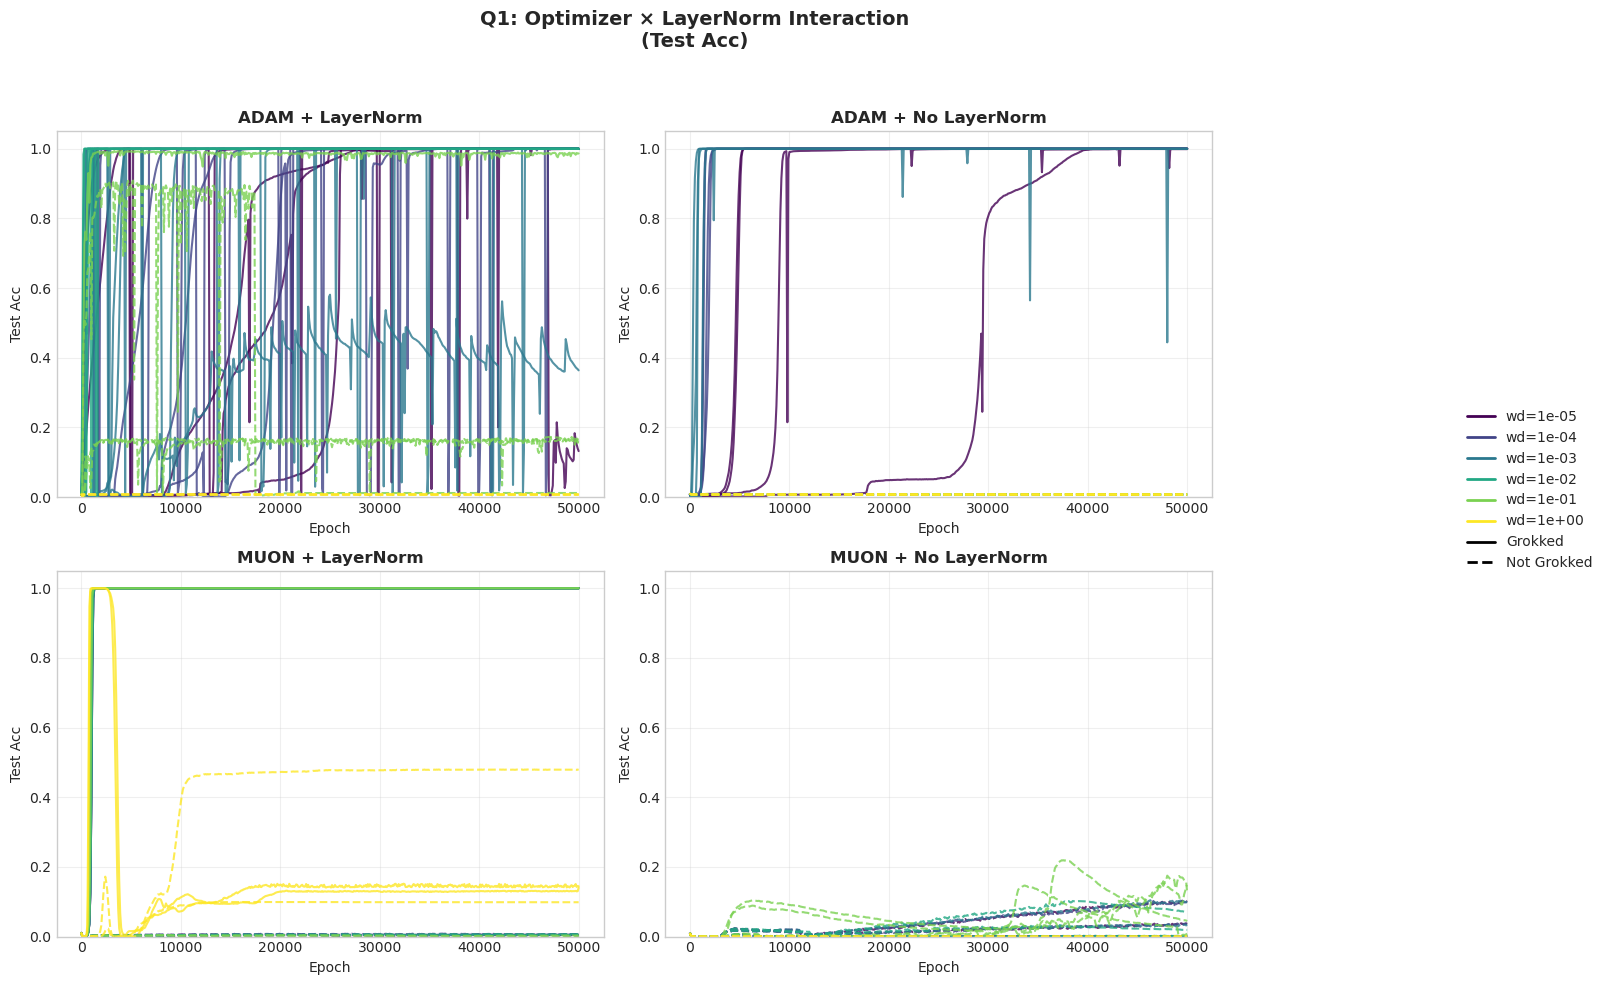

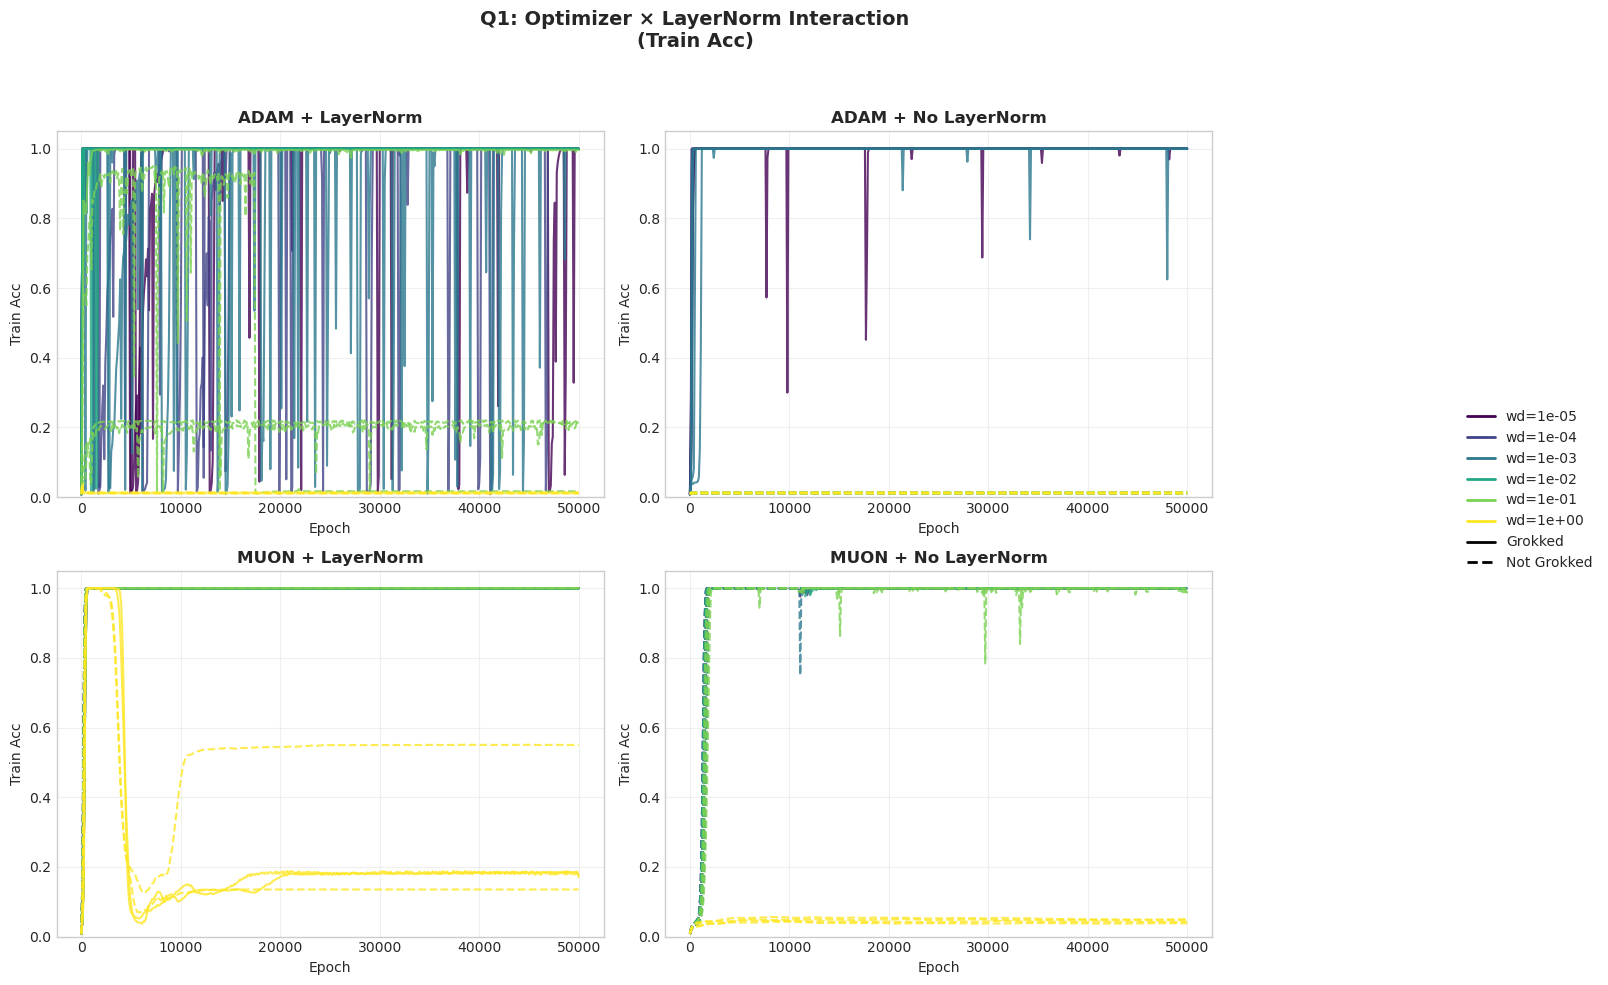

In [56]:
def plot_optimizer_layernorm_dynamics(experiments, metric='test_acc', figsize=(14, 10)):
    """
    Figure 1a: 2×2 panel showing training dynamics for Optimizer × LayerNorm.
    Rows: Adam vs Muon
    Columns: LayerNorm vs No-LayerNorm
    Each panel overlays all weight decays with distinct colors.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    optimizers = ['adam', 'muon']
    layernorms = [True, False]
    
    for row, opt in enumerate(optimizers):
        for col, ln in enumerate(layernorms):
            ax = axes[row, col]
            
            # Filter experiments for this condition
            filtered = [e for e in experiments 
                       if 'history' in e and 
                       e['parsed']['optimizer'] == opt and 
                       e['parsed']['layernorm'] == ln]
            
            # Plot each experiment with weight decay determining color
            for exp in sorted(filtered, key=lambda x: x['parsed']['weight_decay']):
                wd = exp['parsed']['weight_decay']
                history = exp['history']
                epochs = history['epoch']
                values = history[metric]
                
                color = WD_COLORS[wd]
                
                # Detect grokking for linestyle
                grokked, _ = detect_grokking(history)
                linestyle = '-' if grokked else '--'
                
                ax.plot(epochs, values, color=color, 
                       linestyle=linestyle, linewidth=1.5, alpha=0.8)
            
            # Panel title
            ln_label = "LayerNorm" if ln else "No LayerNorm"
            ax.set_title(f"{opt.upper()} + {ln_label}", fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric.replace('_', ' ').title())
            ax.set_ylim([0, 1.05])
            ax.grid(True, alpha=0.3)
    
    # Create legend for weight decays (with distinct colors)
    legend_elements = []
    for wd in WEIGHT_DECAYS:
        legend_elements.append(plt.Line2D([0], [0], color=WD_COLORS[wd], 
                                          linewidth=2, label=f'wd={wd:.0e}'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', 
                                      linewidth=2, label='Grokked'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', 
                                      linewidth=2, label='Not Grokked'))
    
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.suptitle(f'Q1: Optimizer × LayerNorm Interaction\n({metric.replace("_", " ").title()})', 
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.88, 0.95])
    
    return fig

# Plot for test accuracy
fig = plot_optimizer_layernorm_dynamics(experiments, metric='test_acc')
fig.savefig(FIGURES_DIR / 'fig1a_optimizer_layernorm_test_acc.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot for train accuracy
fig = plot_optimizer_layernorm_dynamics(experiments, metric='train_acc')
fig.savefig(FIGURES_DIR / 'fig1a_optimizer_layernorm_train_acc.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 1b: Optimizer × LayerNorm Grokking Rate Heatmap


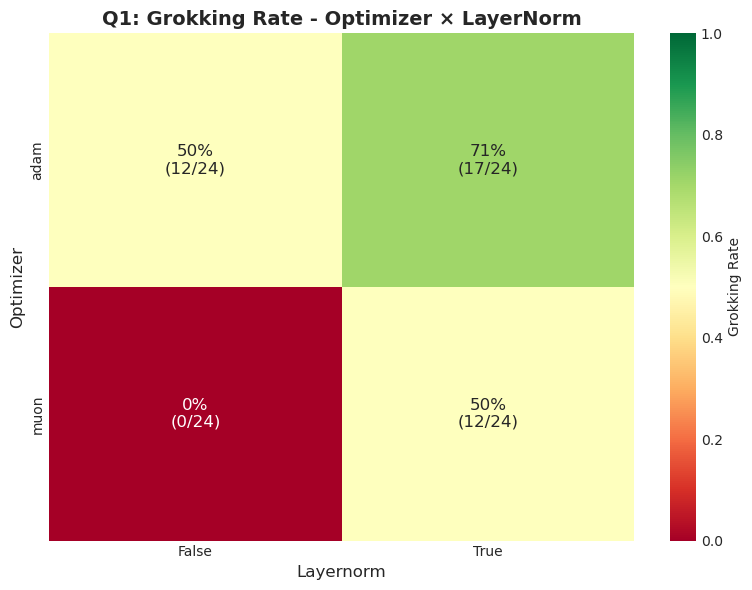

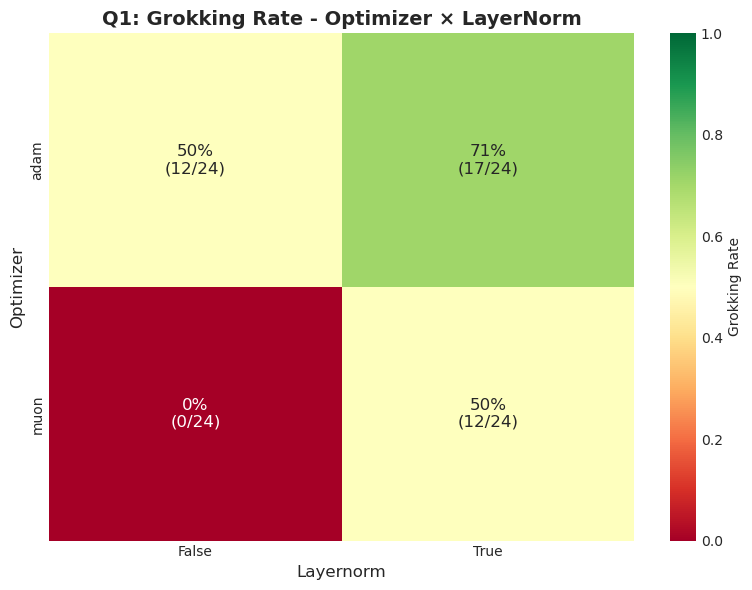

In [57]:
def plot_interaction_heatmap(summary_df, factor1, factor2, title, filename, figsize=(8, 6)):
    """
    Create a 2×2 heatmap showing grokking rate for factor1 × factor2 interaction.
    """
    # Create pivot table for grokking rate
    pivot = summary_df.pivot_table(
        values='grokked',
        index=factor1,
        columns=factor2,
        aggfunc='mean'
    )
    
    # Get sum and count separately for annotations
    sum_pivot = summary_df.pivot_table(
        values='grokked',
        index=factor1,
        columns=factor2,
        aggfunc='sum'
    )
    
    count_pivot = summary_df.pivot_table(
        values='grokked',
        index=factor1,
        columns=factor2,
        aggfunc='count'
    )
    
    # Create annotation strings with rate and counts
    annot = pivot.copy().astype(object)
    for i in pivot.index:
        for j in pivot.columns:
            n_grok = int(sum_pivot.loc[i, j])
            n_total = int(count_pivot.loc[i, j])
            rate = pivot.loc[i, j]
            annot.loc[i, j] = f"{rate:.0%}\n({n_grok}/{n_total})"
    
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(pivot, annot=annot, fmt='', cmap='RdYlGn',
               vmin=0, vmax=1, cbar_kws={'label': 'Grokking Rate'},
               ax=ax, annot_kws={'fontsize': 12})
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(factor2.replace('_', ' ').title(), fontsize=12)
    ax.set_ylabel(factor1.replace('_', ' ').title(), fontsize=12)
    
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

# Figure 1b: Optimizer × LayerNorm
plot_interaction_heatmap(
    summary_df, 
    factor1='optimizer', 
    factor2='layernorm',
    title='Q1: Grokking Rate - Optimizer × LayerNorm',
    filename='fig1b_optimizer_layernorm_heatmap.png'
)


### Figure 2a: Optimizer × Activation Training Dynamics
2×2 panel showing train/test accuracy curves for Optimizer × Attention type (ReLU vs Softmax). Weight decays shown with distinct colors (viridis colormap).


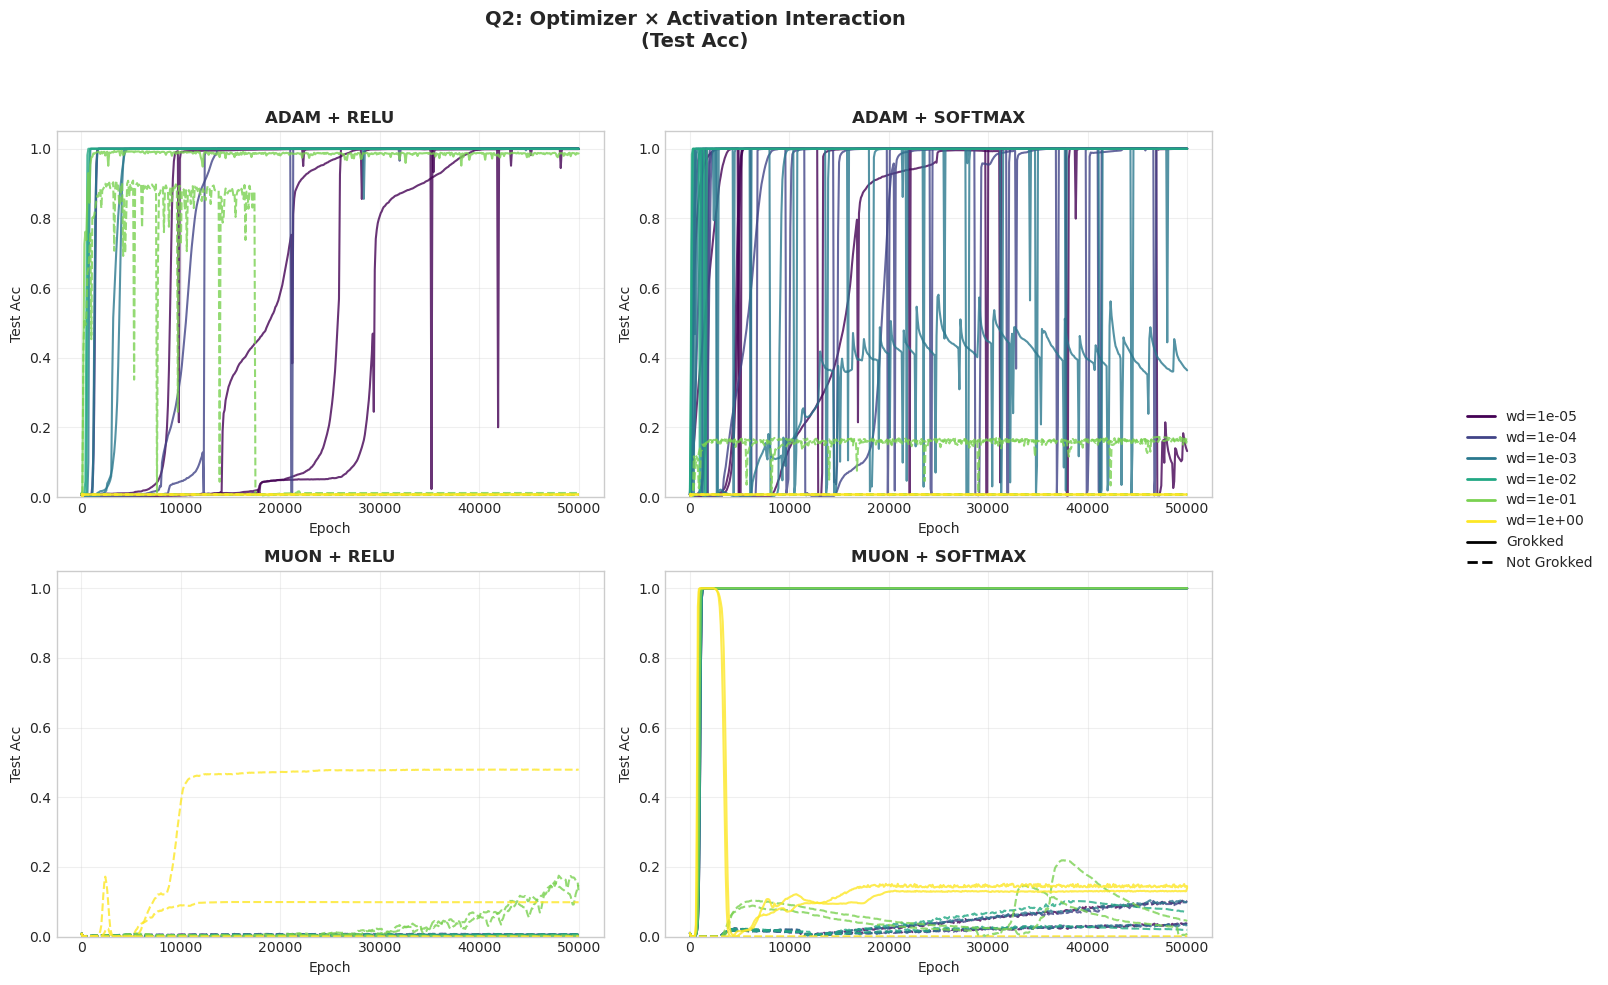

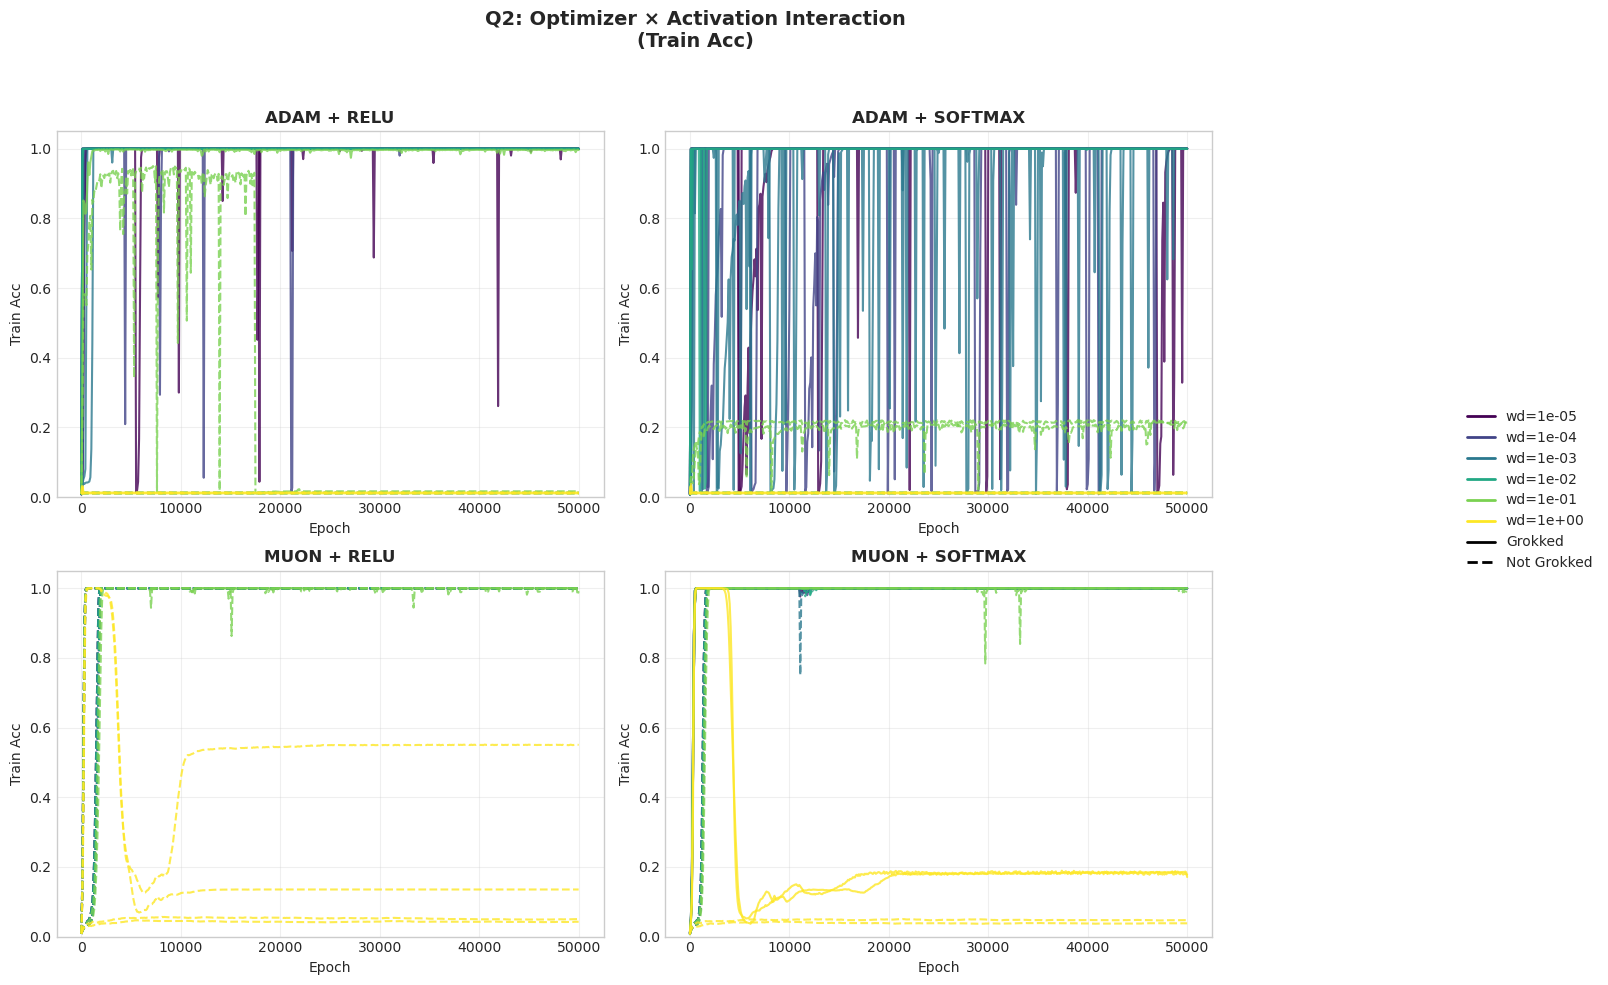

In [58]:
def plot_optimizer_activation_dynamics(experiments, metric='test_acc', figsize=(14, 10)):
    """
    Figure 2a: 2×2 panel showing training dynamics for Optimizer × Activation.
    Rows: Adam vs Muon
    Columns: ReLU vs Softmax
    Each panel overlays all weight decays with distinct colors.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    optimizers = ['adam', 'muon']
    attentions = ['relu', 'softmax']
    
    for row, opt in enumerate(optimizers):
        for col, attn in enumerate(attentions):
            ax = axes[row, col]
            
            # Filter experiments for this condition
            filtered = [e for e in experiments 
                       if 'history' in e and 
                       e['parsed']['optimizer'] == opt and 
                       e['parsed']['attention'] == attn]
            
            # Plot each experiment with weight decay determining color
            for exp in sorted(filtered, key=lambda x: x['parsed']['weight_decay']):
                wd = exp['parsed']['weight_decay']
                history = exp['history']
                epochs = history['epoch']
                values = history[metric]
                
                color = WD_COLORS[wd]
                
                # Detect grokking for linestyle
                grokked, _ = detect_grokking(history)
                linestyle = '-' if grokked else '--'
                
                ax.plot(epochs, values, color=color, 
                       linestyle=linestyle, linewidth=1.5, alpha=0.8)
            
            # Panel title
            ax.set_title(f"{opt.upper()} + {attn.upper()}", fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.set_ylabel(metric.replace('_', ' ').title())
            ax.set_ylim([0, 1.05])
            ax.grid(True, alpha=0.3)
    
    # Create legend for weight decays (with distinct colors)
    legend_elements = []
    for wd in WEIGHT_DECAYS:
        legend_elements.append(plt.Line2D([0], [0], color=WD_COLORS[wd], 
                                          linewidth=2, label=f'wd={wd:.0e}'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='-', 
                                      linewidth=2, label='Grokked'))
    legend_elements.append(plt.Line2D([0], [0], color='black', linestyle='--', 
                                      linewidth=2, label='Not Grokked'))
    
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.15, 0.5))
    
    plt.suptitle(f'Q2: Optimizer × Activation Interaction\n({metric.replace("_", " ").title()})', 
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 0.88, 0.95])
    
    return fig

# Plot for test accuracy
fig = plot_optimizer_activation_dynamics(experiments, metric='test_acc')
fig.savefig(FIGURES_DIR / 'fig2a_optimizer_activation_test_acc.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot for train accuracy
fig = plot_optimizer_activation_dynamics(experiments, metric='train_acc')
fig.savefig(FIGURES_DIR / 'fig2a_optimizer_activation_train_acc.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 2b: Optimizer × Activation Grokking Rate Heatmap


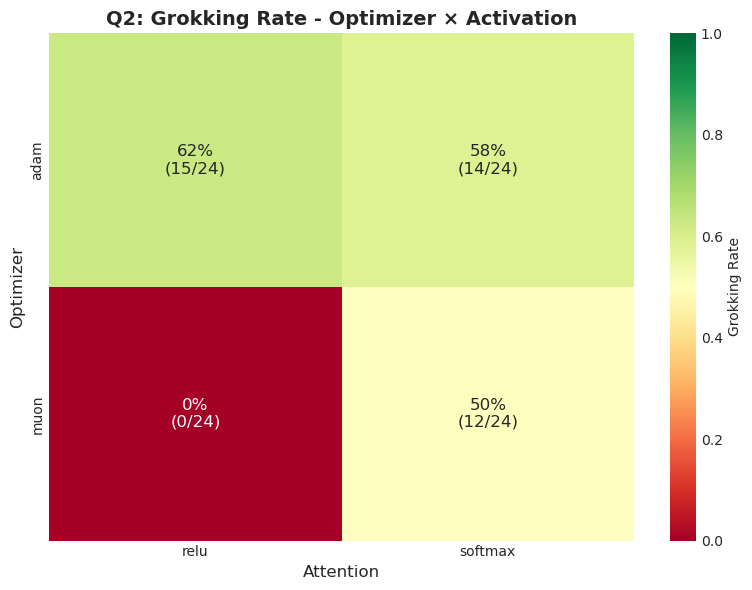

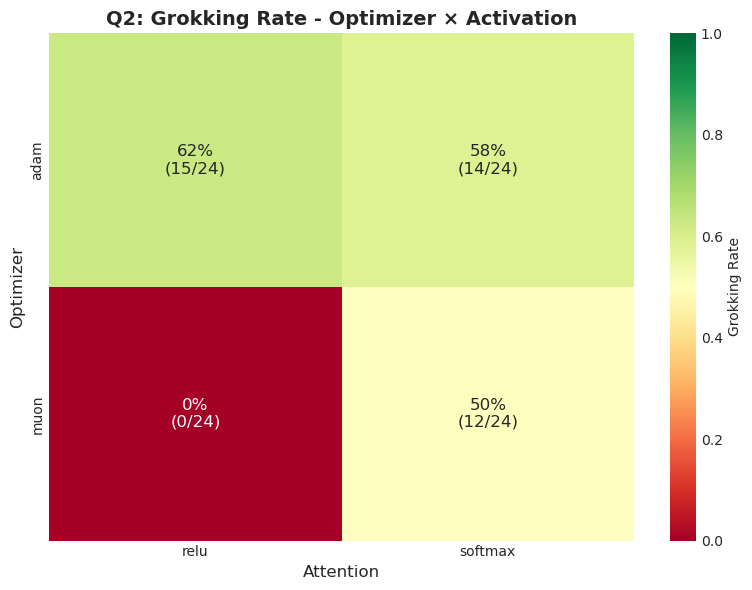

In [59]:
# Figure 2b: Optimizer × Activation
plot_interaction_heatmap(
    summary_df, 
    factor1='optimizer', 
    factor2='attention',
    title='Q2: Grokking Rate - Optimizer × Activation',
    filename='fig2b_optimizer_activation_heatmap.png'
)


### Figure 3a: Weight Decay Sensitivity - Optimizer × LayerNorm
Shows how grokking rate changes across weight decay values, faceted by LayerNorm condition.


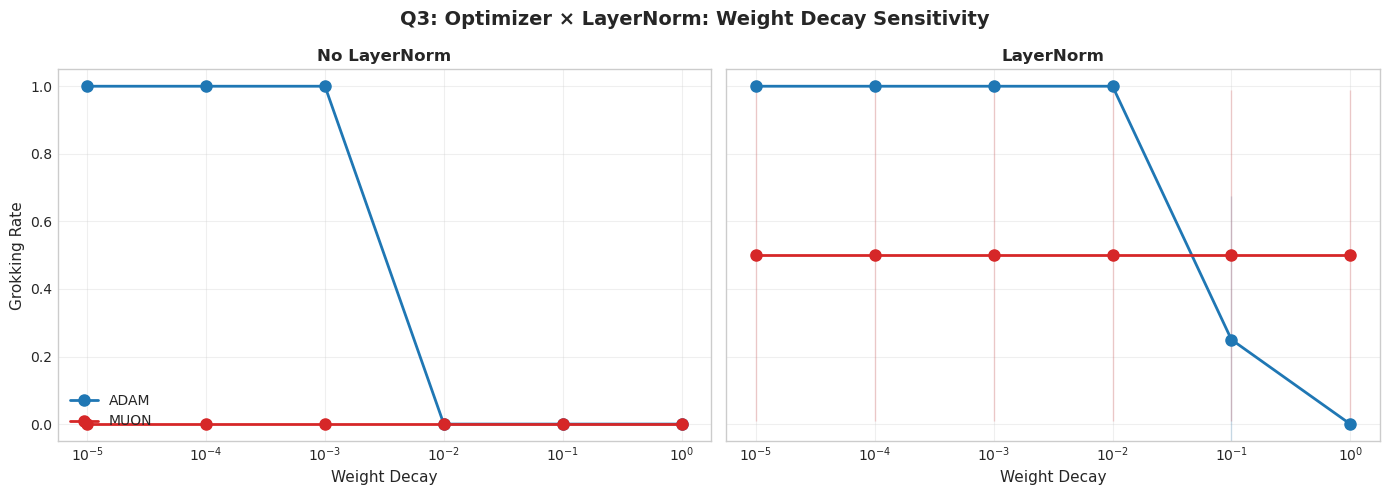

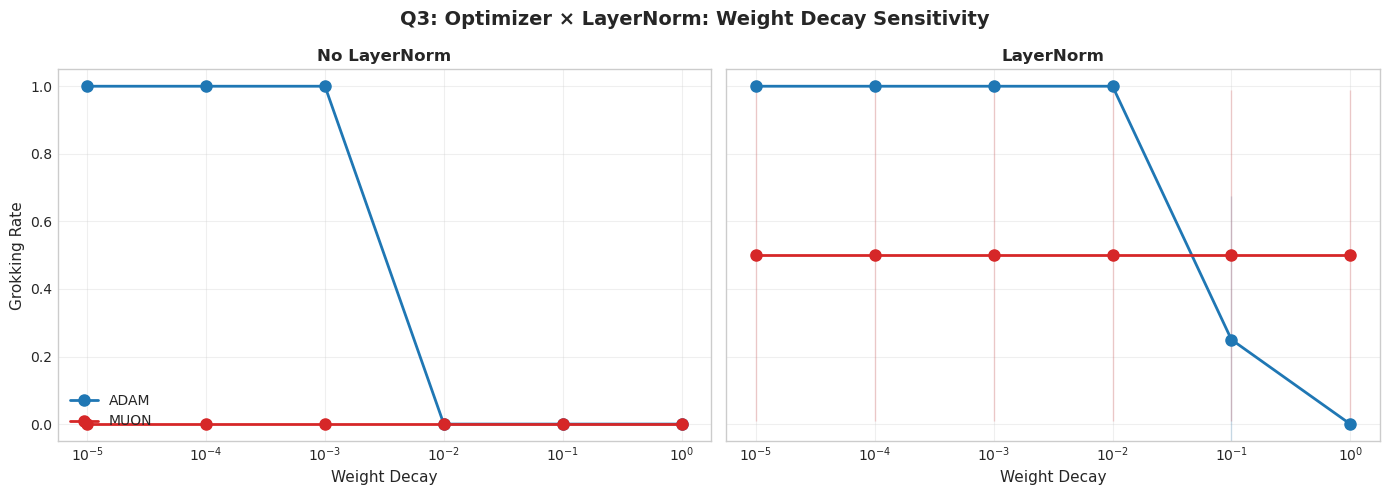

In [60]:
def plot_weight_decay_sensitivity(summary_df, facet_factor, title_prefix, filename, figsize=(14, 5)):
    """
    Figure 3: Weight decay sensitivity plots.
    X-axis: Weight decay (log scale)
    Y-axis: Grokking rate
    Lines: Optimizer (Adam/Muon)
    Facets: Based on facet_factor (e.g., layernorm or attention)
    """
    facet_values = sorted(summary_df[facet_factor].unique())
    n_facets = len(facet_values)
    
    fig, axes = plt.subplots(1, n_facets, figsize=figsize, sharey=True)
    if n_facets == 1:
        axes = [axes]
    
    for idx, facet_val in enumerate(facet_values):
        ax = axes[idx]
        subset = summary_df[summary_df[facet_factor] == facet_val]
        
        for opt in ['adam', 'muon']:
            opt_subset = subset[subset['optimizer'] == opt]
            
            # Compute grokking rate per weight decay
            wd_stats = opt_subset.groupby('weight_decay').agg({
                'grokked': ['mean', 'sum', 'count']
            }).reset_index()
            wd_stats.columns = ['weight_decay', 'grok_rate', 'n_grokked', 'n_total']
            
            ax.plot(wd_stats['weight_decay'], wd_stats['grok_rate'], 
                   color=OPTIMIZER_COLORS[opt], marker='o', markersize=8,
                   linewidth=2, label=opt.upper())
            
            # Add error region (binomial confidence)
            for _, row in wd_stats.iterrows():
                n = row['n_total']
                p = row['grok_rate']
                se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
                ax.fill_between([row['weight_decay']], [p - 1.96*se], [p + 1.96*se],
                              color=OPTIMIZER_COLORS[opt], alpha=0.2)
        
        # Format facet label
        if facet_factor == 'layernorm':
            facet_label = "LayerNorm" if facet_val else "No LayerNorm"
        elif facet_factor == 'attention':
            facet_label = facet_val.upper()
        else:
            facet_label = str(facet_val)
        
        ax.set_title(facet_label, fontsize=12, fontweight='bold')
        ax.set_xlabel('Weight Decay', fontsize=11)
        ax.set_xscale('log')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.set_ylabel('Grokking Rate', fontsize=11)
            ax.legend(loc='lower left')
    
    plt.suptitle(f'{title_prefix}: Weight Decay Sensitivity', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

# Figure 3a: Weight Decay Sensitivity by LayerNorm
plot_weight_decay_sensitivity(
    summary_df,
    facet_factor='layernorm',
    title_prefix='Q3: Optimizer × LayerNorm',
    filename='fig3a_wd_sensitivity_layernorm.png'
)


### Figure 3b: Weight Decay Sensitivity - Optimizer × Activation


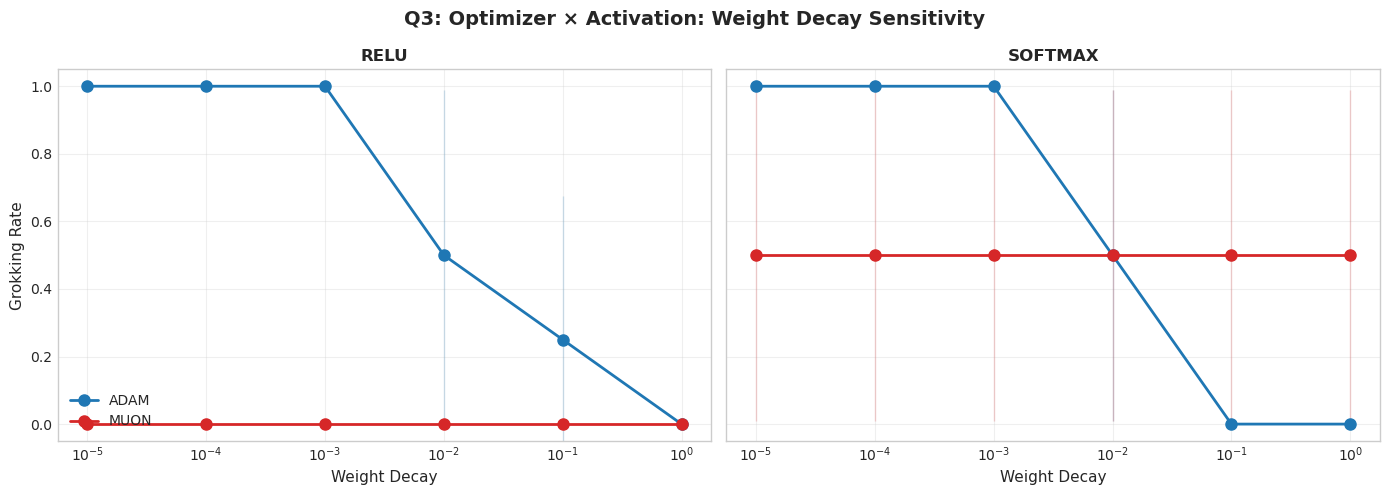

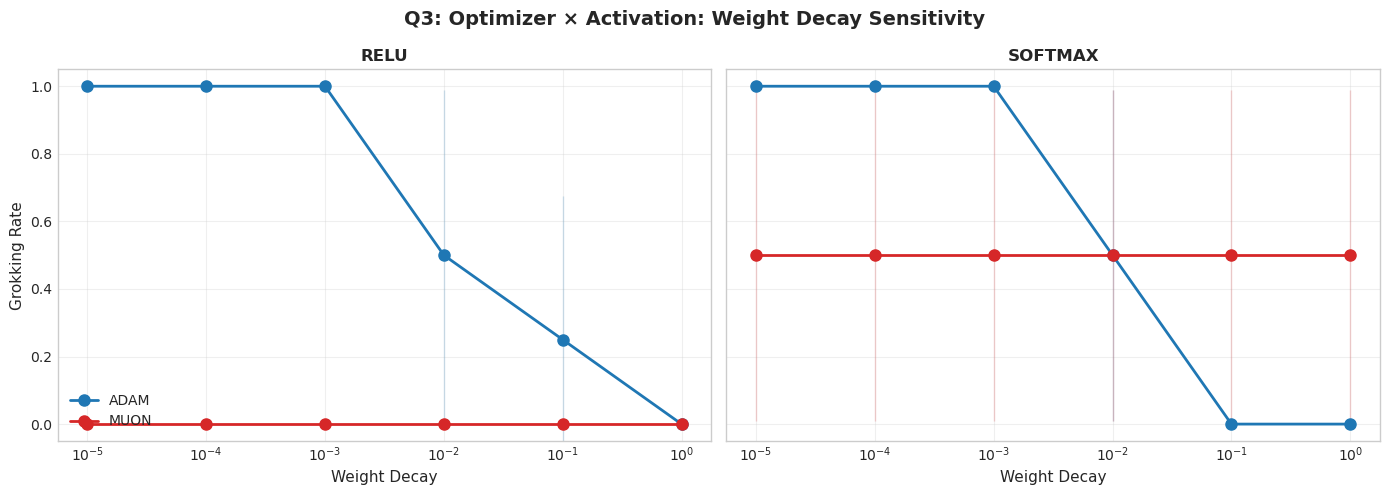

In [61]:
# Figure 3b: Weight Decay Sensitivity by Activation
plot_weight_decay_sensitivity(
    summary_df,
    facet_factor='attention',
    title_prefix='Q3: Optimizer × Activation',
    filename='fig3b_wd_sensitivity_activation.png'
)


### Figure 4a: Dataset Comparison - Optimizer × LayerNorm by Modulus
Side-by-side comparison of grokking rate interactions for p=97 vs p=113.


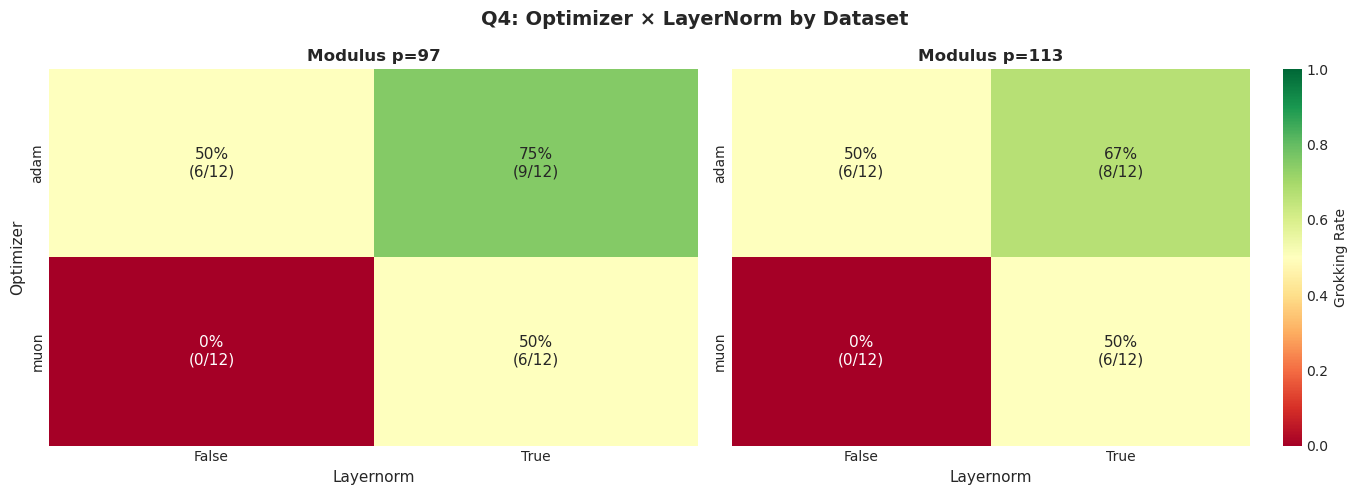

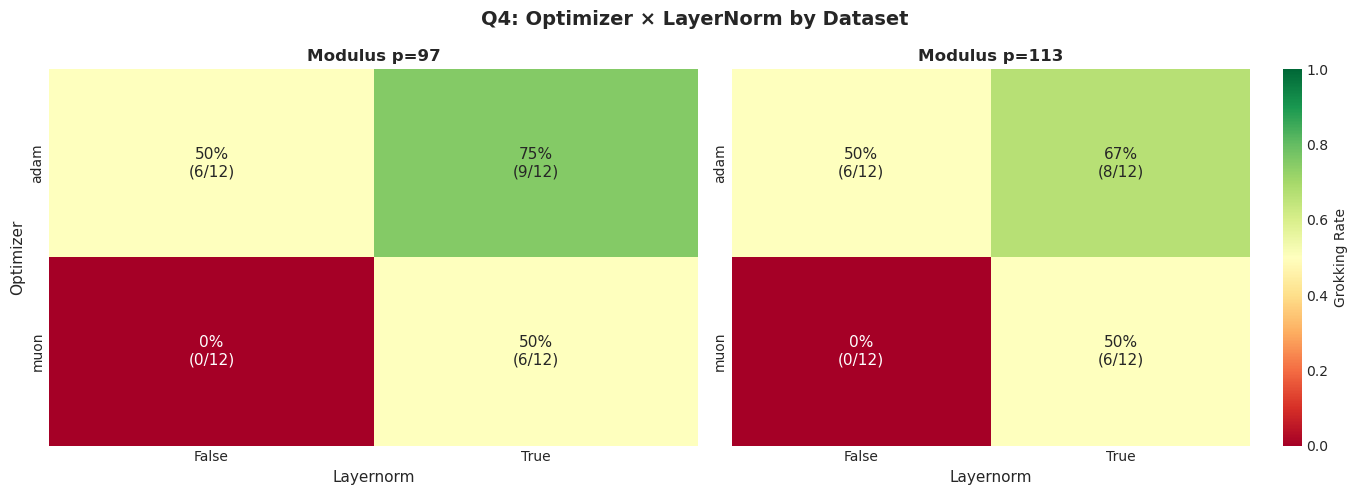

In [62]:
def plot_modulus_comparison_heatmaps(summary_df, factor1, factor2, title_prefix, filename, figsize=(14, 5)):
    """
    Figure 4a: Side-by-side heatmaps for p=97 vs p=113.
    """
    moduli = sorted(summary_df['modulus'].unique())
    
    fig, axes = plt.subplots(1, len(moduli), figsize=figsize)
    
    for idx, modulus in enumerate(moduli):
        ax = axes[idx]
        subset = summary_df[summary_df['modulus'] == modulus]
        
        # Create pivot table for grokking rate
        pivot = subset.pivot_table(
            values='grokked',
            index=factor1,
            columns=factor2,
            aggfunc='mean'
        )
        
        # Get sum and count separately for annotations
        sum_pivot = subset.pivot_table(
            values='grokked',
            index=factor1,
            columns=factor2,
            aggfunc='sum'
        )
        
        count_pivot = subset.pivot_table(
            values='grokked',
            index=factor1,
            columns=factor2,
            aggfunc='count'
        )
        
        # Create annotation strings
        annot = pivot.copy().astype(object)
        for i in pivot.index:
            for j in pivot.columns:
                n_grok = int(sum_pivot.loc[i, j])
                n_total = int(count_pivot.loc[i, j])
                rate = pivot.loc[i, j]
                annot.loc[i, j] = f"{rate:.0%}\n({n_grok}/{n_total})"
        
        sns.heatmap(pivot, annot=annot, fmt='', cmap='RdYlGn',
                   vmin=0, vmax=1, cbar=idx == len(moduli) - 1,
                   cbar_kws={'label': 'Grokking Rate'} if idx == len(moduli) - 1 else {},
                   ax=ax, annot_kws={'fontsize': 11})
        
        ax.set_title(f'Modulus p={modulus}', fontsize=12, fontweight='bold')
        ax.set_xlabel(factor2.replace('_', ' ').title(), fontsize=11)
        ax.set_ylabel(factor1.replace('_', ' ').title() if idx == 0 else '', fontsize=11)
    
    plt.suptitle(f'{title_prefix}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

# Figure 4a: Modulus comparison for Optimizer × LayerNorm
plot_modulus_comparison_heatmaps(
    summary_df,
    factor1='optimizer',
    factor2='layernorm',
    title_prefix='Q4: Optimizer × LayerNorm by Dataset',
    filename='fig4a_modulus_optimizer_layernorm.png'
)


### Figure 4b: Dataset Comparison - Weight Decay Sensitivity by Modulus


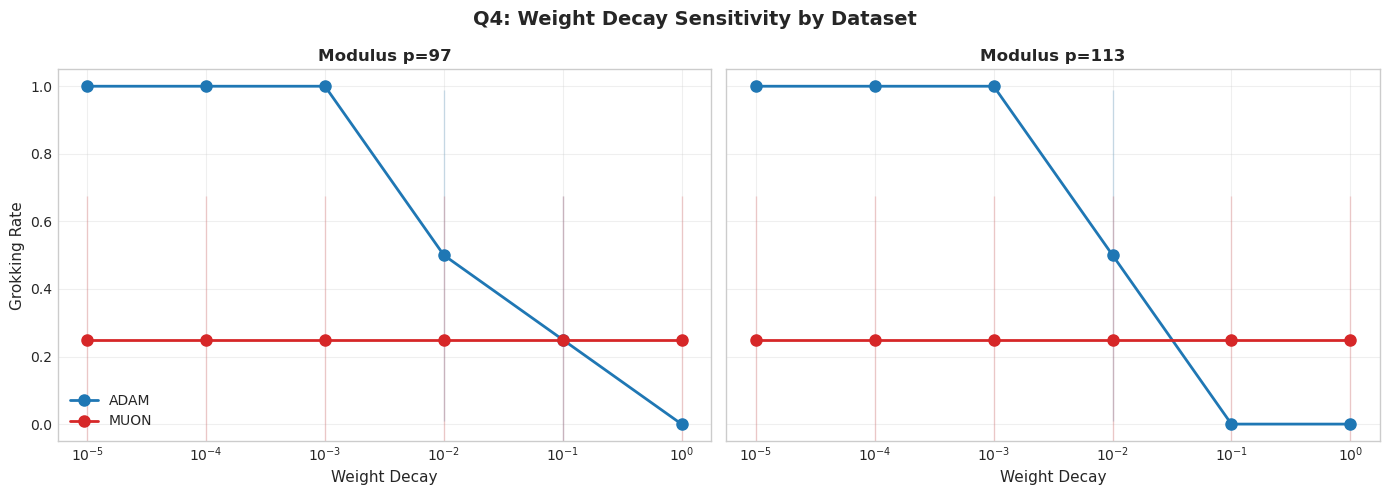

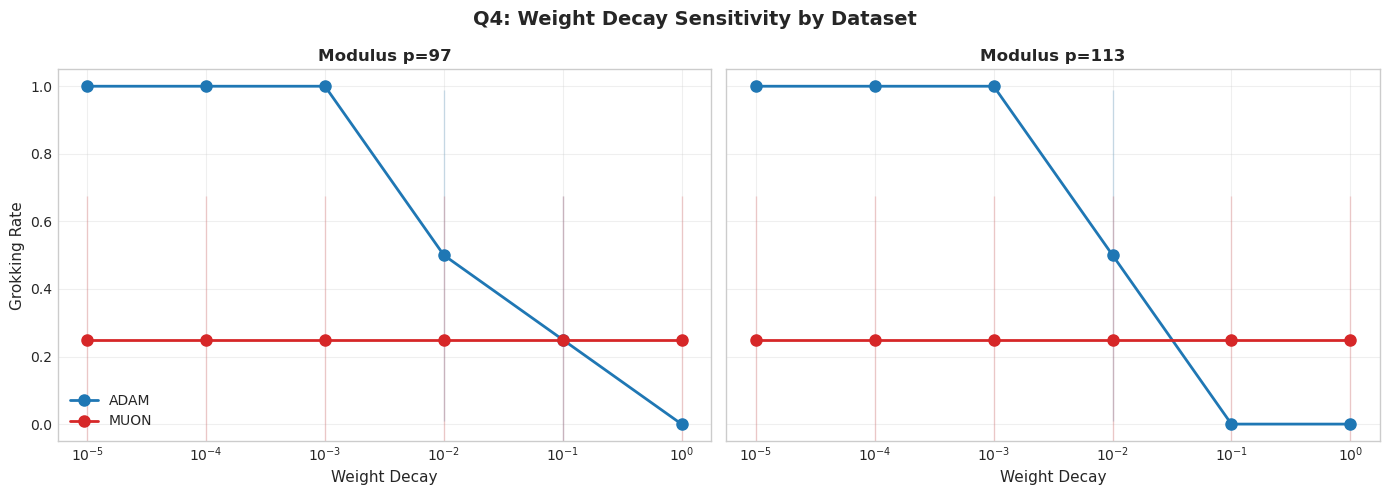

In [63]:
def plot_modulus_wd_sensitivity(summary_df, figsize=(14, 5)):
    """
    Figure 4b: Weight decay sensitivity comparison for p=97 vs p=113.
    """
    moduli = sorted(summary_df['modulus'].unique())
    
    fig, axes = plt.subplots(1, len(moduli), figsize=figsize, sharey=True)
    
    for idx, modulus in enumerate(moduli):
        ax = axes[idx]
        subset = summary_df[summary_df['modulus'] == modulus]
        
        for opt in ['adam', 'muon']:
            opt_subset = subset[subset['optimizer'] == opt]
            
            # Compute grokking rate per weight decay
            wd_stats = opt_subset.groupby('weight_decay').agg({
                'grokked': ['mean', 'sum', 'count']
            }).reset_index()
            wd_stats.columns = ['weight_decay', 'grok_rate', 'n_grokked', 'n_total']
            
            ax.plot(wd_stats['weight_decay'], wd_stats['grok_rate'], 
                   color=OPTIMIZER_COLORS[opt], marker='o', markersize=8,
                   linewidth=2, label=opt.upper())
            
            # Add error region
            for _, row in wd_stats.iterrows():
                n = row['n_total']
                p = row['grok_rate']
                se = np.sqrt(p * (1 - p) / n) if n > 0 else 0
                ax.fill_between([row['weight_decay']], [p - 1.96*se], [p + 1.96*se],
                              color=OPTIMIZER_COLORS[opt], alpha=0.2)
        
        ax.set_title(f'Modulus p={modulus}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Weight Decay', fontsize=11)
        ax.set_xscale('log')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3)
        
        if idx == 0:
            ax.set_ylabel('Grokking Rate', fontsize=11)
            ax.legend(loc='lower left')
    
    plt.suptitle('Q4: Weight Decay Sensitivity by Dataset', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    fig.savefig(FIGURES_DIR / 'fig4b_modulus_wd_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

# Figure 4b: Weight Decay Sensitivity by Modulus
plot_modulus_wd_sensitivity(summary_df)


### Figure 5: Full Factorial Summary Heatmap
Comprehensive heatmap showing grokking rate for all factor combinations.
Rows: All 8 architecture configs (modulus × attention × layernorm)
Columns: Optimizer × Weight Decay combinations


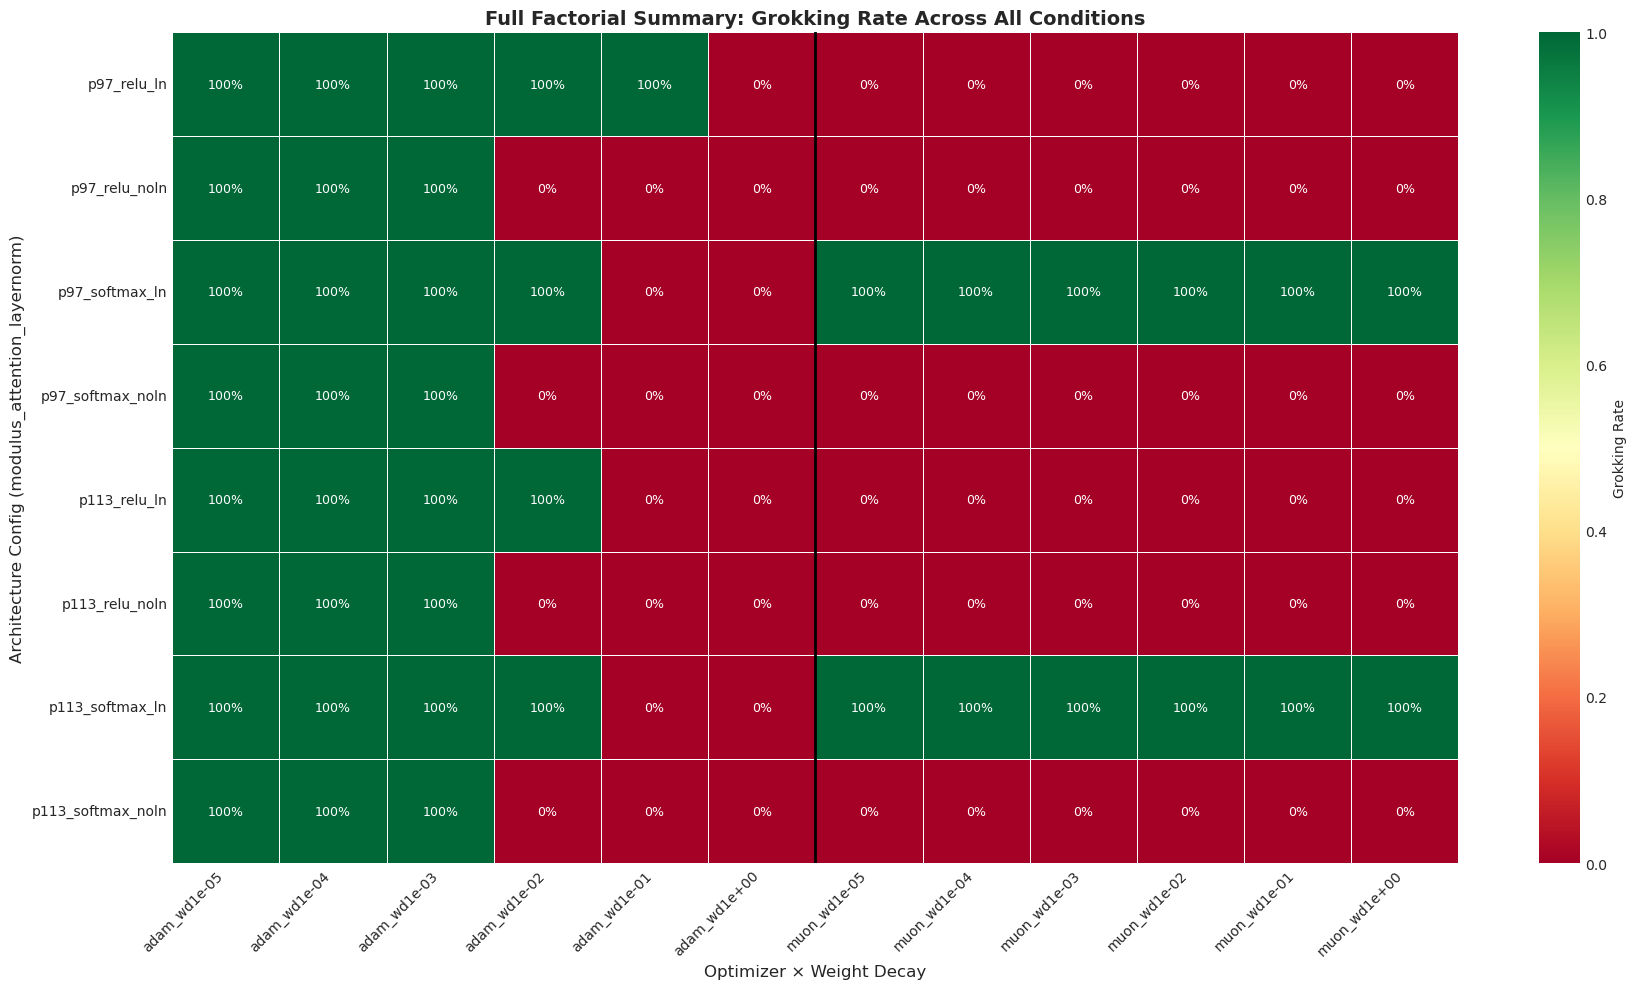

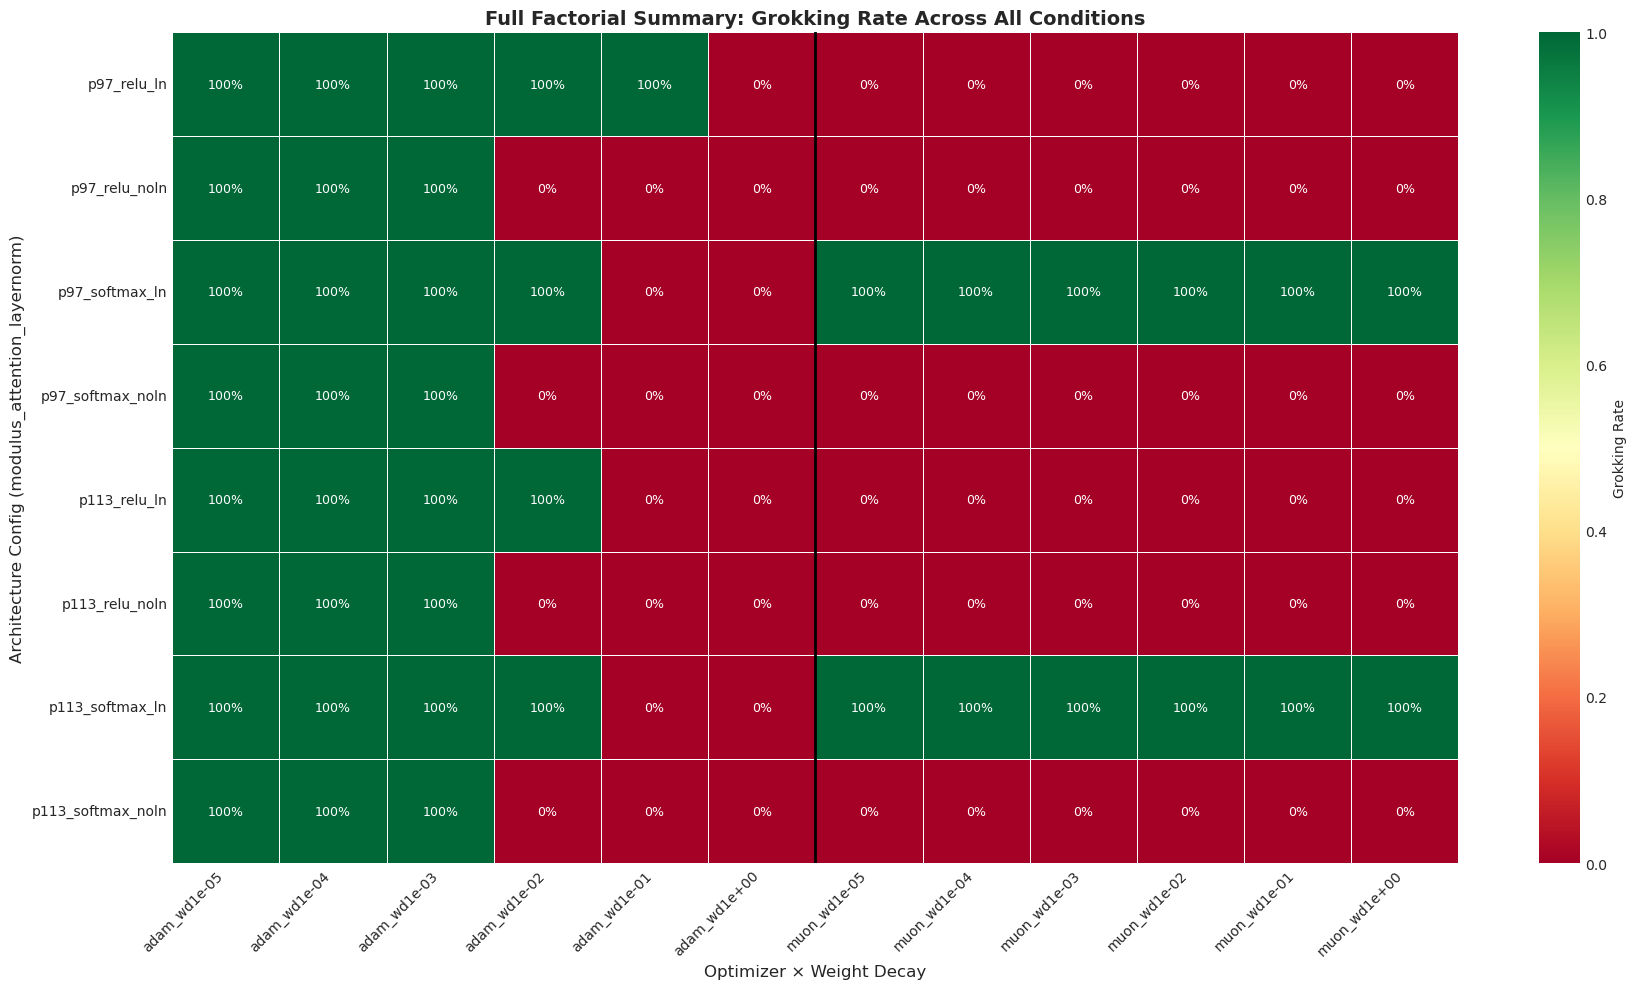

In [64]:
def plot_full_factorial_summary(summary_df, figsize=(18, 10)):
    """
    Figure 5: Full factorial summary heatmap.
    Rows: All 8 architecture configs (modulus × attention × layernorm)
    Columns: Optimizer × Weight Decay combinations
    """
    df = summary_df.copy()
    
    # Create architecture config string (row label)
    df['arch_config'] = ('p' + df['modulus'].astype(str) + '_' + 
                        df['attention'] + '_' + 
                        df['layernorm'].map({True: 'ln', False: 'noln'}))
    
    # Create optimizer × weight decay string (column label)
    df['opt_wd'] = df['optimizer'] + '_wd' + df['weight_decay'].apply(lambda x: f'{x:.0e}')
    
    # Create pivot table
    pivot = df.pivot_table(
        values='grokked',
        index='arch_config',
        columns='opt_wd',
        aggfunc='mean'
    )
    
    # Sort columns by optimizer then weight decay
    col_order = []
    for opt in ['adam', 'muon']:
        for wd in sorted(df['weight_decay'].unique()):
            col_name = f'{opt}_wd{wd:.0e}'
            if col_name in pivot.columns:
                col_order.append(col_name)
    pivot = pivot[col_order]
    
    # Sort rows by modulus, attention, layernorm
    row_order = sorted(pivot.index, key=lambda x: (
        int(x.split('_')[0][1:]),  # modulus
        x.split('_')[1],            # attention
        x.split('_')[2]             # layernorm
    ))
    pivot = pivot.loc[row_order]
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn',
               vmin=0, vmax=1, cbar_kws={'label': 'Grokking Rate'},
               ax=ax, annot_kws={'fontsize': 9}, linewidths=0.5)
    
    ax.set_title('Full Factorial Summary: Grokking Rate Across All Conditions', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Optimizer × Weight Decay', fontsize=12)
    ax.set_ylabel('Architecture Config (modulus_attention_layernorm)', fontsize=12)
    
    # Rotate x labels
    plt.xticks(rotation=45, ha='right')
    
    # Add vertical line to separate optimizers
    n_wds = len(df['weight_decay'].unique())
    ax.axvline(x=n_wds, color='black', linewidth=2)
    
    plt.tight_layout()
    
    fig.savefig(FIGURES_DIR / 'fig5_full_factorial_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

# Figure 5: Full Factorial Summary
plot_full_factorial_summary(summary_df)


### Summary: Key Findings by Research Question


In [65]:
def print_summary_statistics(summary_df):
    """Print key statistics for each research question."""
    
    print("=" * 70)
    print("RESEARCH QUESTION SUMMARY STATISTICS")
    print("=" * 70)
    
    # Q1: Optimizer × LayerNorm
    print("\n" + "=" * 70)
    print("Q1: OPTIMIZER × LAYERNORM INTERACTION")
    print("=" * 70)
    for opt in ['adam', 'muon']:
        for ln in [True, False]:
            subset = summary_df[(summary_df['optimizer'] == opt) & 
                               (summary_df['layernorm'] == ln)]
            rate = subset['grokked'].mean()
            ln_label = "LayerNorm" if ln else "No LayerNorm"
            print(f"  {opt.upper():5s} + {ln_label:12s}: {rate:.1%} ({subset['grokked'].sum()}/{len(subset)})")
    
    # Q2: Optimizer × Activation
    print("\n" + "=" * 70)
    print("Q2: OPTIMIZER × ACTIVATION INTERACTION")
    print("=" * 70)
    for opt in ['adam', 'muon']:
        for attn in ['relu', 'softmax']:
            subset = summary_df[(summary_df['optimizer'] == opt) & 
                               (summary_df['attention'] == attn)]
            rate = subset['grokked'].mean()
            print(f"  {opt.upper():5s} + {attn.upper():8s}: {rate:.1%} ({subset['grokked'].sum()}/{len(subset)})")
    
    # Q3: Weight Decay Sensitivity
    print("\n" + "=" * 70)
    print("Q3: WEIGHT DECAY SENSITIVITY (Overall)")
    print("=" * 70)
    wd_stats = summary_df.groupby(['optimizer', 'weight_decay'])['grokked'].agg(['mean', 'sum', 'count'])
    print(wd_stats.round(2))
    
    # Q4: Dataset Comparison
    print("\n" + "=" * 70)
    print("Q4: DATASET (MODULUS) COMPARISON")
    print("=" * 70)
    for mod in [97, 113]:
        subset = summary_df[summary_df['modulus'] == mod]
        rate = subset['grokked'].mean()
        print(f"  p={mod}: {rate:.1%} ({subset['grokked'].sum()}/{len(subset)})")
    
    # Overall statistics
    print("\n" + "=" * 70)
    print("OVERALL STATISTICS")
    print("=" * 70)
    print(f"  Total experiments: {len(summary_df)}")
    print(f"  Overall grokking rate: {summary_df['grokked'].mean():.1%}")
    grokked = summary_df[summary_df['grokked']]
    if len(grokked) > 0:
        print(f"  Mean grokking epoch (when grokked): {grokked['grok_epoch'].mean():.0f}")
        print(f"  Median grokking epoch (when grokked): {grokked['grok_epoch'].median():.0f}")
    
    print("\n" + "=" * 70)
    print("FIGURES SAVED TO:", FIGURES_DIR.absolute())
    print("=" * 70)

print_summary_statistics(summary_df)


RESEARCH QUESTION SUMMARY STATISTICS

Q1: OPTIMIZER × LAYERNORM INTERACTION
  ADAM  + LayerNorm   : 70.8% (17/24)
  ADAM  + No LayerNorm: 50.0% (12/24)
  MUON  + LayerNorm   : 50.0% (12/24)
  MUON  + No LayerNorm: 0.0% (0/24)

Q2: OPTIMIZER × ACTIVATION INTERACTION
  ADAM  + RELU    : 62.5% (15/24)
  ADAM  + SOFTMAX : 58.3% (14/24)
  MUON  + RELU    : 0.0% (0/24)
  MUON  + SOFTMAX : 50.0% (12/24)

Q3: WEIGHT DECAY SENSITIVITY (Overall)
                        mean  sum  count
optimizer weight_decay                  
adam      0.00001       1.00    8      8
          0.00010       1.00    8      8
          0.00100       1.00    8      8
          0.01000       0.50    4      8
          0.10000       0.12    1      8
          1.00000       0.00    0      8
muon      0.00001       0.25    2      8
          0.00010       0.25    2      8
          0.00100       0.25    2      8
          0.01000       0.25    2      8
          0.10000       0.25    2      8
          1.00000       0.2

## 9. Controlled Comparison Analysis

Isolating the effect of each factor while holding all other factors constant. This provides cleaner causal estimates of each factor's impact on grokking.


In [66]:
def controlled_comparison(summary_df, vary_factor, control_factors, figsize=(16, 10)):
    """
    Create controlled comparison plots.
    
    For each unique combination of control_factors, compare the two values of vary_factor.
    This isolates the effect of vary_factor while holding everything else constant.
    
    Args:
        summary_df: DataFrame with experiment results
        vary_factor: The factor to compare (e.g., 'layernorm', 'attention', 'optimizer')
        control_factors: List of factors to hold constant (e.g., ['attention', 'optimizer', 'modulus'])
    """
    # Get unique values of the varying factor
    vary_values = sorted(summary_df[vary_factor].unique())
    
    # Get all unique combinations of control factors
    control_combos = summary_df.groupby(control_factors).size().reset_index()[control_factors]
    n_combos = len(control_combos)
    
    # Determine grid size
    n_cols = min(4, n_combos)
    n_rows = (n_combos + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharey=True)
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    axes = axes.flatten()
    
    # Colors for the varying factor values
    if vary_factor == 'optimizer':
        colors = {vary_values[0]: OPTIMIZER_COLORS.get(vary_values[0], '#1f77b4'),
                  vary_values[1]: OPTIMIZER_COLORS.get(vary_values[1], '#d62728')}
    else:
        colors = {vary_values[0]: '#2ecc71', vary_values[1]: '#e74c3c'}  # Green vs Red
    
    comparison_results = []
    
    for idx, row in control_combos.iterrows():
        ax = axes[idx]
        
        # Build filter for this control combination
        mask = pd.Series([True] * len(summary_df))
        title_parts = []
        for cf in control_factors:
            mask &= (summary_df[cf] == row[cf])
            # Format the label
            if cf == 'layernorm':
                label = 'LN' if row[cf] else 'NoLN'
            elif cf == 'attention':
                label = row[cf].upper()
            elif cf == 'optimizer':
                label = row[cf].upper()
            elif cf == 'modulus':
                label = f'p={row[cf]}'
            else:
                label = str(row[cf])
            title_parts.append(label)
        
        subset = summary_df[mask]
        
        # For each value of the varying factor, compute grokking rate by weight decay
        for val in vary_values:
            val_subset = subset[subset[vary_factor] == val]
            
            wd_stats = val_subset.groupby('weight_decay').agg({
                'grokked': ['mean', 'sum', 'count']
            }).reset_index()
            wd_stats.columns = ['weight_decay', 'grok_rate', 'n_grokked', 'n_total']
            
            # Format label for varying factor
            if vary_factor == 'layernorm':
                val_label = 'LayerNorm' if val else 'No LayerNorm'
            elif vary_factor == 'attention':
                val_label = val.upper()
            elif vary_factor == 'optimizer':
                val_label = val.upper()
            else:
                val_label = str(val)
            
            ax.plot(wd_stats['weight_decay'], wd_stats['grok_rate'],
                   color=colors[val], marker='o', markersize=6,
                   linewidth=2, label=val_label)
            
            # Store overall comparison
            overall_rate = val_subset['grokked'].mean()
            comparison_results.append({
                'control': ' + '.join(title_parts),
                vary_factor: val_label,
                'grok_rate': overall_rate,
                'n_grokked': val_subset['grokked'].sum(),
                'n_total': len(val_subset)
            })
        
        ax.set_title(' + '.join(title_parts), fontsize=10, fontweight='bold')
        ax.set_xlabel('Weight Decay')
        ax.set_xscale('log')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc='lower left')
        
        if idx % n_cols == 0:
            ax.set_ylabel('Grokking Rate')
    
    # Hide empty subplots
    for idx in range(n_combos, len(axes)):
        axes[idx].set_visible(False)
    
    # Format title
    vary_label = vary_factor.replace('_', ' ').title()
    if vary_factor == 'layernorm':
        vary_label = 'LayerNorm'
    
    plt.suptitle(f'Controlled Comparison: Effect of {vary_label}\n(holding {", ".join(control_factors)} constant)',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    return fig, pd.DataFrame(comparison_results)


### 9.1 Effect of LayerNorm (controlling for Activation, Optimizer, Modulus)

For each combination of (Activation, Optimizer, Modulus), compare LayerNorm ON vs OFF.


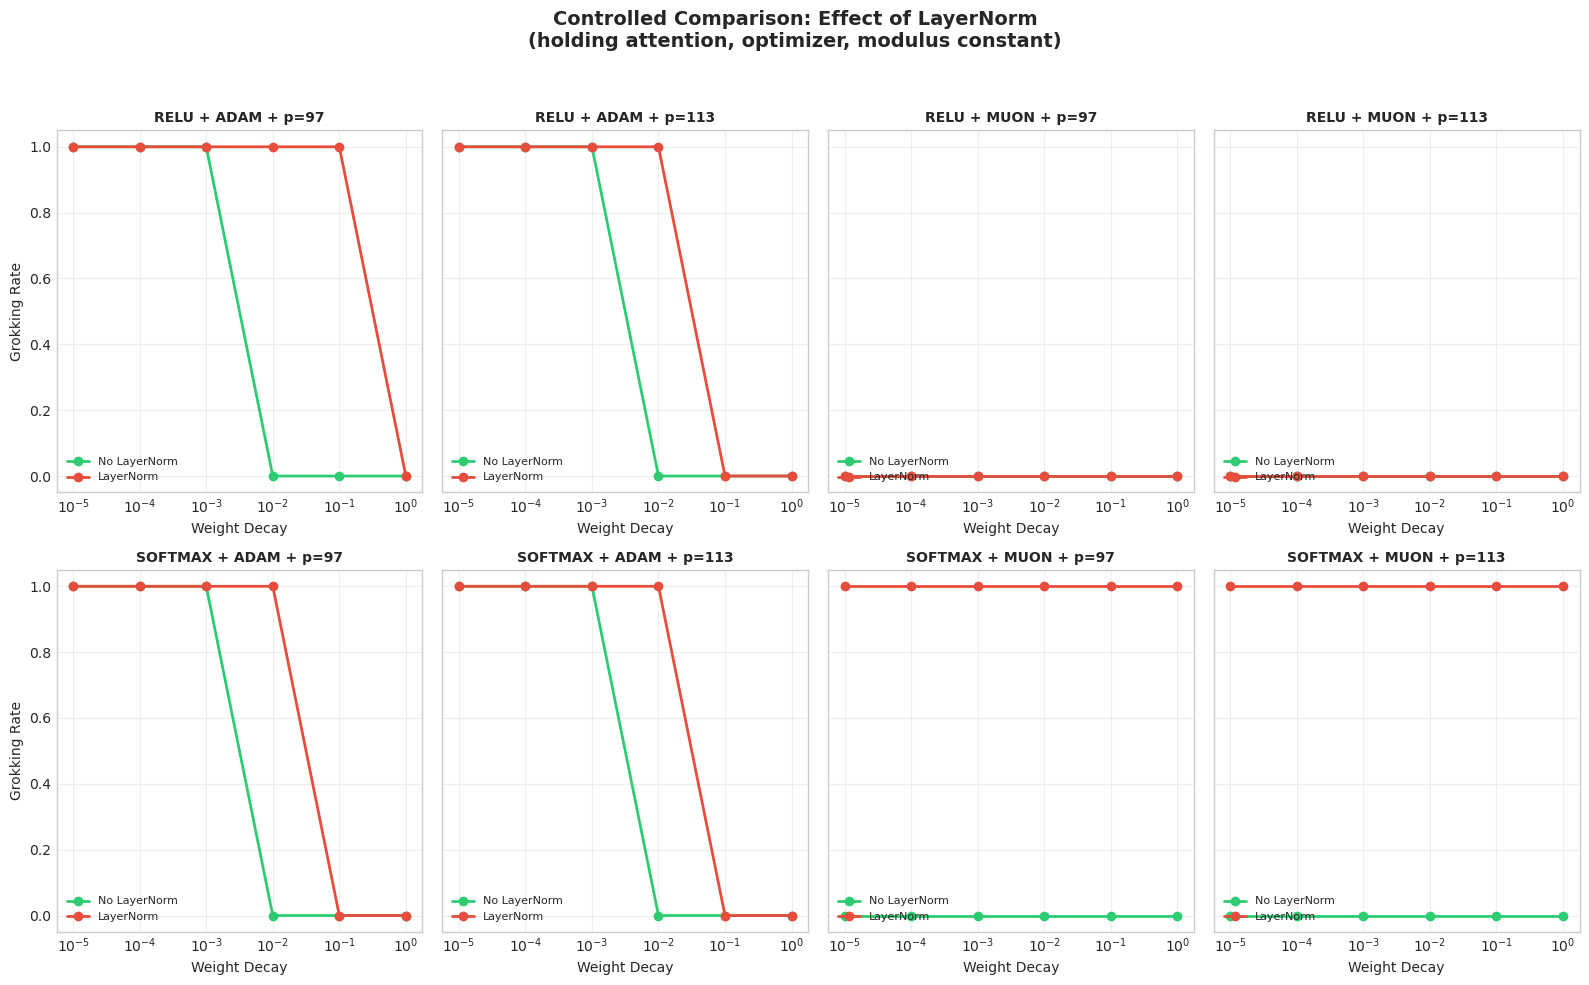


LayerNorm Effect Summary (averaged across weight decays):
layernorm               LayerNorm  No LayerNorm  Δ (LN - NoLN)
control                                                       
RELU + ADAM + p=113         0.667           0.5          0.167
RELU + ADAM + p=97          0.833           0.5          0.333
RELU + MUON + p=113         0.000           0.0          0.000
RELU + MUON + p=97          0.000           0.0          0.000
SOFTMAX + ADAM + p=113      0.667           0.5          0.167
SOFTMAX + ADAM + p=97       0.667           0.5          0.167
SOFTMAX + MUON + p=113      1.000           0.0          1.000
SOFTMAX + MUON + p=97       1.000           0.0          1.000

Mean effect of LayerNorm: 35.4%
LayerNorm helps in 6/8 conditions


In [67]:
# Controlled comparison: Effect of LayerNorm
fig_ln, results_ln = controlled_comparison(
    summary_df, 
    vary_factor='layernorm',
    control_factors=['attention', 'optimizer', 'modulus']
)
fig_ln.savefig(FIGURES_DIR / 'fig6a_controlled_layernorm.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nLayerNorm Effect Summary (averaged across weight decays):")
print("=" * 70)
pivot_ln = results_ln.pivot_table(values='grok_rate', index='control', columns='layernorm')
pivot_ln['Δ (LN - NoLN)'] = pivot_ln['LayerNorm'] - pivot_ln['No LayerNorm']
print(pivot_ln.round(3))
print(f"\nMean effect of LayerNorm: {pivot_ln['Δ (LN - NoLN)'].mean():.1%}")
print(f"LayerNorm helps in {(pivot_ln['Δ (LN - NoLN)'] > 0).sum()}/{len(pivot_ln)} conditions")


### 9.2 Effect of Activation (controlling for LayerNorm, Optimizer, Modulus)

For each combination of (LayerNorm, Optimizer, Modulus), compare ReLU vs Softmax attention.


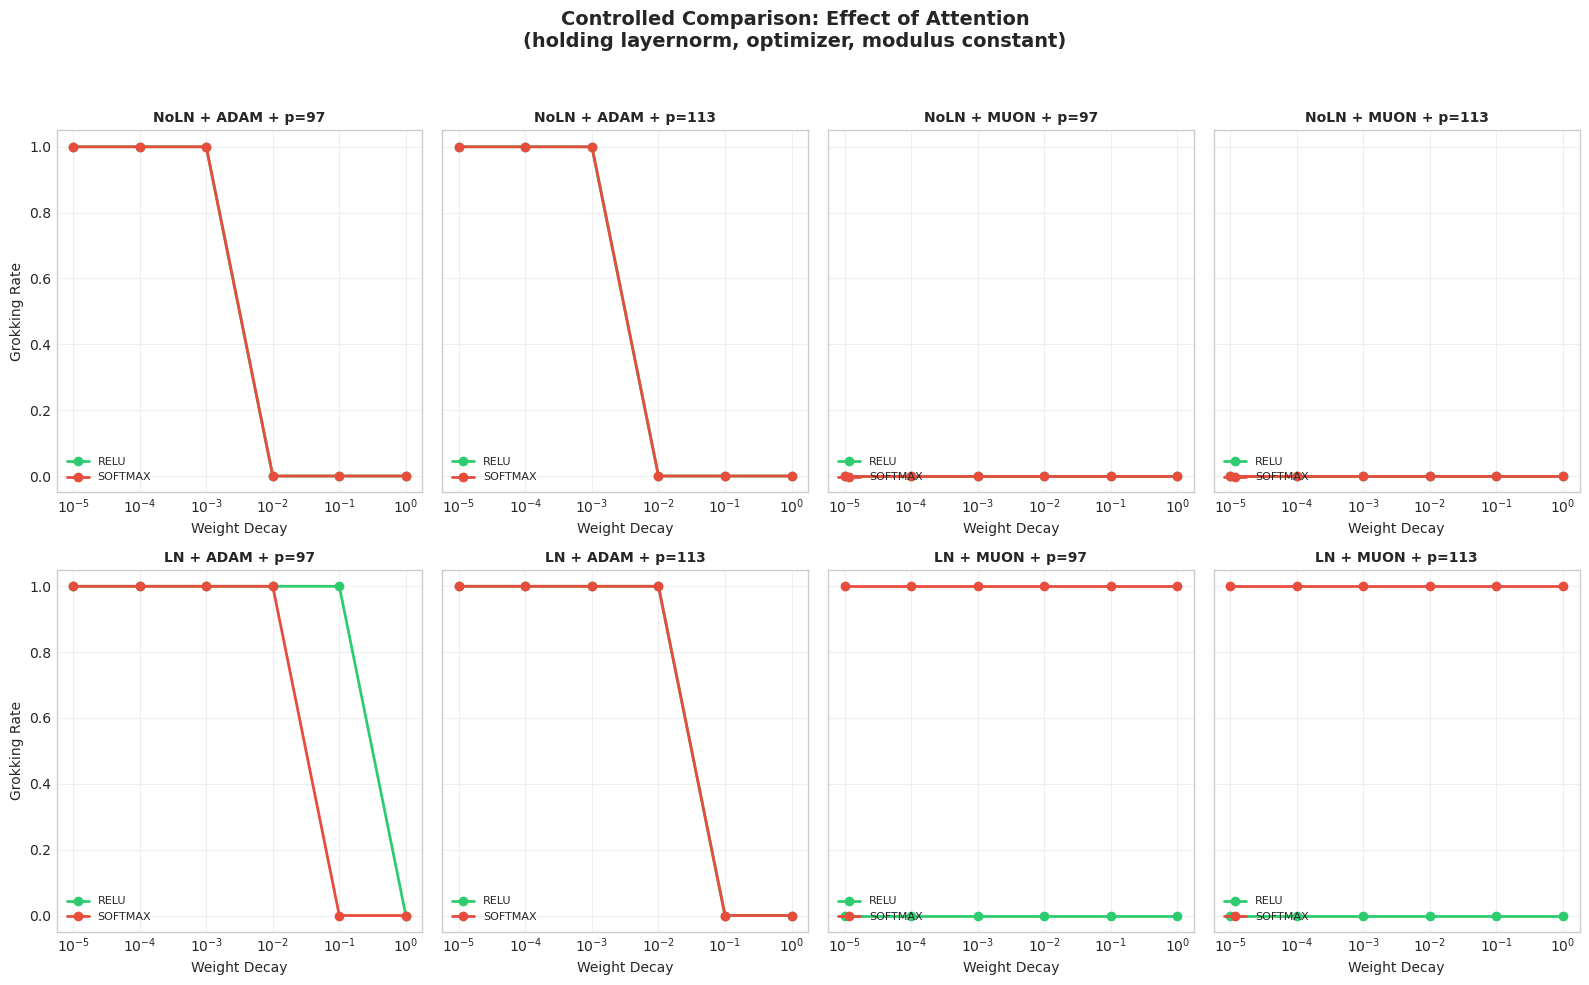


Activation Effect Summary (averaged across weight decays):
attention             RELU  SOFTMAX  Δ (Softmax - ReLU)
control                                                
LN + ADAM + p=113    0.667    0.667               0.000
LN + ADAM + p=97     0.833    0.667              -0.167
LN + MUON + p=113    0.000    1.000               1.000
LN + MUON + p=97     0.000    1.000               1.000
NoLN + ADAM + p=113  0.500    0.500               0.000
NoLN + ADAM + p=97   0.500    0.500               0.000
NoLN + MUON + p=113  0.000    0.000               0.000
NoLN + MUON + p=97   0.000    0.000               0.000

Mean effect of Softmax over ReLU: 22.9%
Softmax helps in 2/8 conditions


In [68]:
# Controlled comparison: Effect of Activation
fig_attn, results_attn = controlled_comparison(
    summary_df, 
    vary_factor='attention',
    control_factors=['layernorm', 'optimizer', 'modulus']
)
fig_attn.savefig(FIGURES_DIR / 'fig6b_controlled_activation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nActivation Effect Summary (averaged across weight decays):")
print("=" * 70)
pivot_attn = results_attn.pivot_table(values='grok_rate', index='control', columns='attention')
pivot_attn['Δ (Softmax - ReLU)'] = pivot_attn['SOFTMAX'] - pivot_attn['RELU']
print(pivot_attn.round(3))
print(f"\nMean effect of Softmax over ReLU: {pivot_attn['Δ (Softmax - ReLU)'].mean():.1%}")
print(f"Softmax helps in {(pivot_attn['Δ (Softmax - ReLU)'] > 0).sum()}/{len(pivot_attn)} conditions")


### 9.3 Effect of Optimizer (controlling for LayerNorm, Activation, Modulus)

For each combination of (LayerNorm, Activation, Modulus), compare Adam vs Muon.


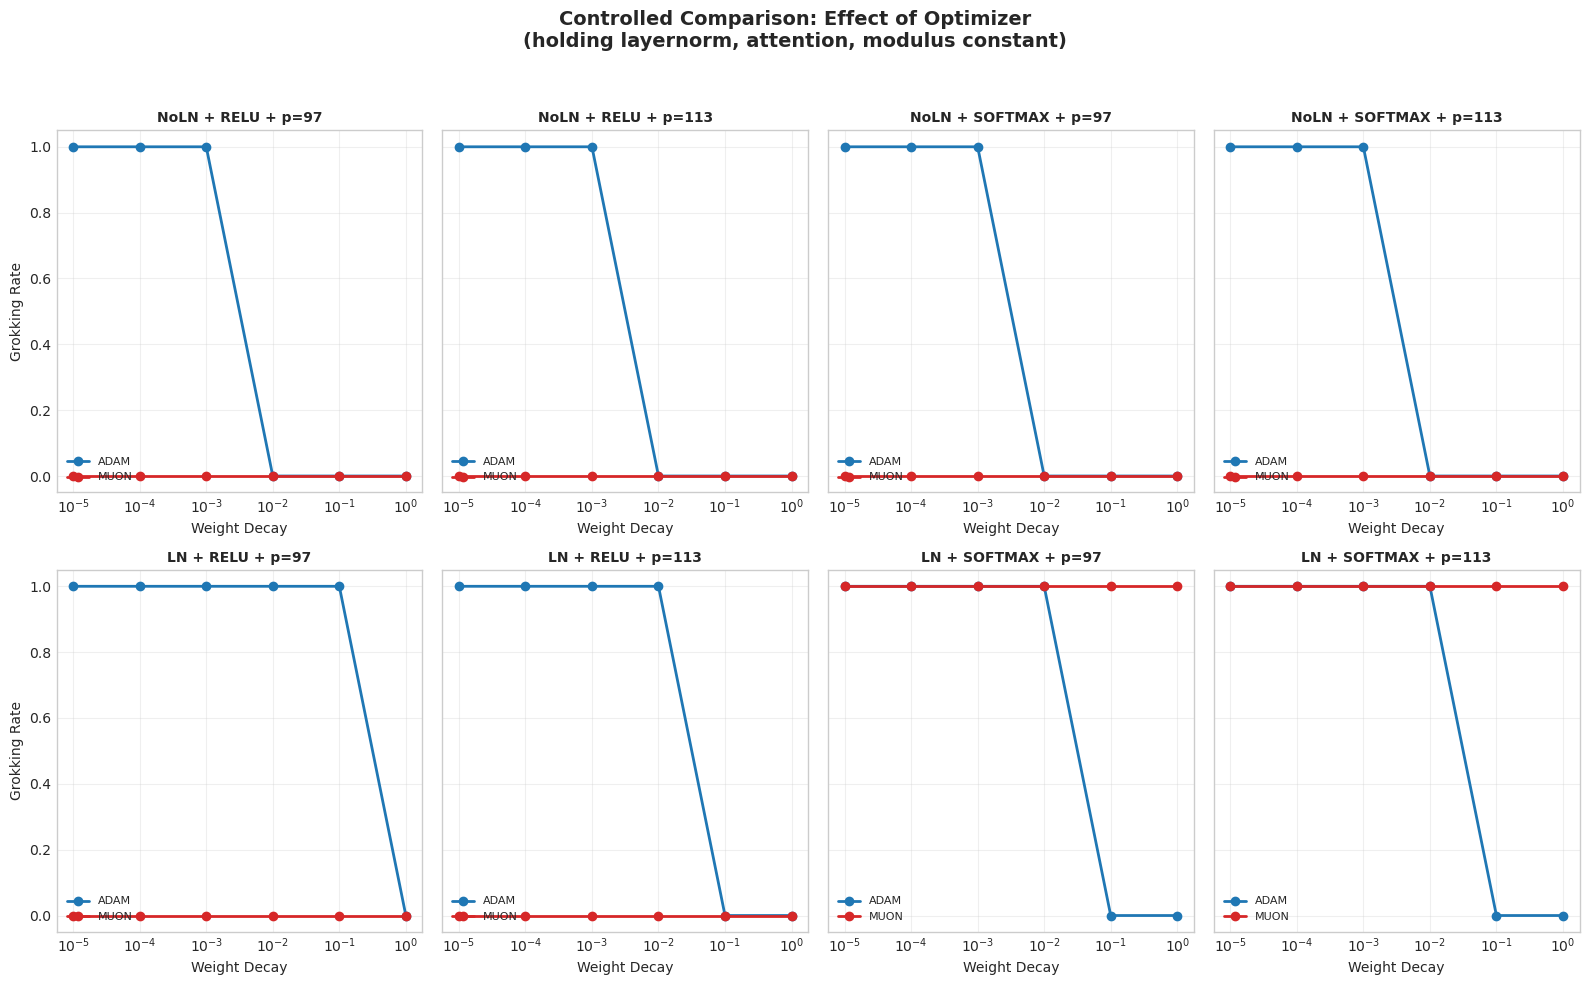


Optimizer Effect Summary (averaged across weight decays):
optimizer                ADAM  MUON  Δ (Adam - Muon)
control                                             
LN + RELU + p=113       0.667   0.0            0.667
LN + RELU + p=97        0.833   0.0            0.833
LN + SOFTMAX + p=113    0.667   1.0           -0.333
LN + SOFTMAX + p=97     0.667   1.0           -0.333
NoLN + RELU + p=113     0.500   0.0            0.500
NoLN + RELU + p=97      0.500   0.0            0.500
NoLN + SOFTMAX + p=113  0.500   0.0            0.500
NoLN + SOFTMAX + p=97   0.500   0.0            0.500

Mean effect of Adam over Muon: 35.4%
Adam helps in 6/8 conditions


In [69]:
# Controlled comparison: Effect of Optimizer
fig_opt, results_opt = controlled_comparison(
    summary_df, 
    vary_factor='optimizer',
    control_factors=['layernorm', 'attention', 'modulus']
)
fig_opt.savefig(FIGURES_DIR / 'fig6c_controlled_optimizer.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\nOptimizer Effect Summary (averaged across weight decays):")
print("=" * 70)
pivot_opt = results_opt.pivot_table(values='grok_rate', index='control', columns='optimizer')
pivot_opt['Δ (Adam - Muon)'] = pivot_opt['ADAM'] - pivot_opt['MUON']
print(pivot_opt.round(3))
print(f"\nMean effect of Adam over Muon: {pivot_opt['Δ (Adam - Muon)'].mean():.1%}")
print(f"Adam helps in {(pivot_opt['Δ (Adam - Muon)'] > 0).sum()}/{len(pivot_opt)} conditions")


### 9.4 Controlled Comparison Summary

Combined view of all factor effects when controlling for other variables.


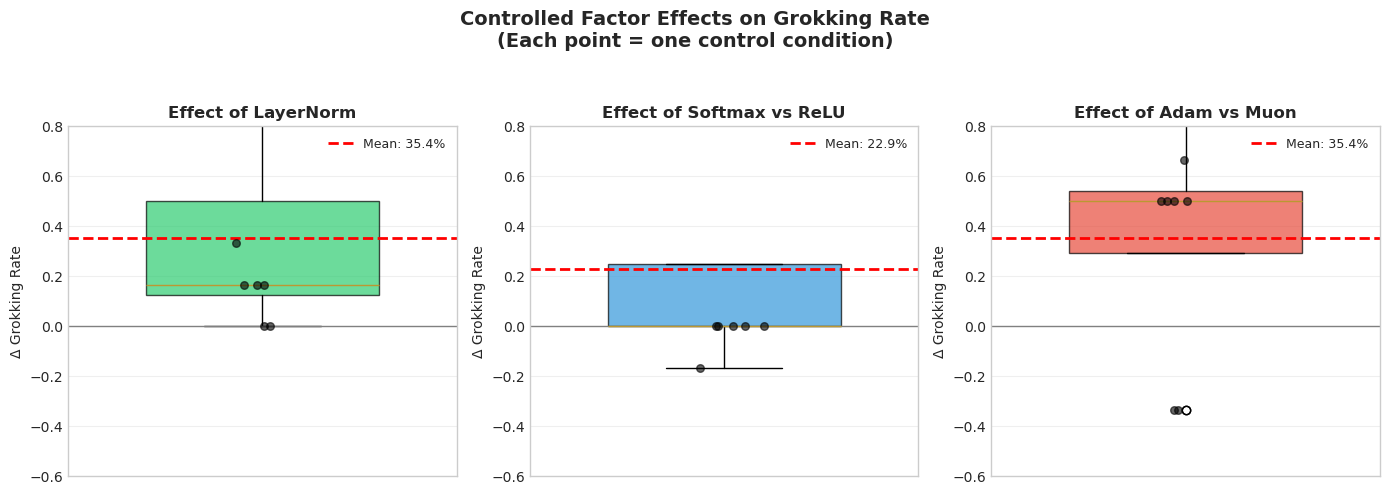


CONTROLLED COMPARISON SUMMARY

LayerNorm:
  Mean effect: 35.4%
  Std effect:  41.2%
  Min effect:  0.0%
  Max effect:  100.0%
  Positive in: 6/8 conditions (75%)

Softmax vs ReLU:
  Mean effect: 22.9%
  Std effect:  47.9%
  Min effect:  -16.7%
  Max effect:  100.0%
  Positive in: 2/8 conditions (25%)

Adam vs Muon:
  Mean effect: 35.4%
  Std effect:  44.0%
  Min effect:  -33.3%
  Max effect:  83.3%
  Positive in: 6/8 conditions (75%)


In [70]:
def plot_controlled_summary(summary_df, figsize=(14, 5)):
    """
    Create a summary bar chart showing the average effect of each factor
    when controlling for all other factors.
    """
    # Calculate controlled effects for each factor
    effects = []
    
    # LayerNorm effect
    for _, row in summary_df.groupby(['attention', 'optimizer', 'modulus']).size().reset_index()[['attention', 'optimizer', 'modulus']].iterrows():
        mask = (summary_df['attention'] == row['attention']) & \
               (summary_df['optimizer'] == row['optimizer']) & \
               (summary_df['modulus'] == row['modulus'])
        subset = summary_df[mask]
        ln_rate = subset[subset['layernorm'] == True]['grokked'].mean()
        noln_rate = subset[subset['layernorm'] == False]['grokked'].mean()
        effects.append({'factor': 'LayerNorm', 'condition': f"{row['attention']}_{row['optimizer']}_p{row['modulus']}", 
                       'effect': ln_rate - noln_rate})
    
    # Activation effect
    for _, row in summary_df.groupby(['layernorm', 'optimizer', 'modulus']).size().reset_index()[['layernorm', 'optimizer', 'modulus']].iterrows():
        mask = (summary_df['layernorm'] == row['layernorm']) & \
               (summary_df['optimizer'] == row['optimizer']) & \
               (summary_df['modulus'] == row['modulus'])
        subset = summary_df[mask]
        softmax_rate = subset[subset['attention'] == 'softmax']['grokked'].mean()
        relu_rate = subset[subset['attention'] == 'relu']['grokked'].mean()
        effects.append({'factor': 'Softmax vs ReLU', 'condition': f"{'LN' if row['layernorm'] else 'NoLN'}_{row['optimizer']}_p{row['modulus']}", 
                       'effect': softmax_rate - relu_rate})
    
    # Optimizer effect
    for _, row in summary_df.groupby(['layernorm', 'attention', 'modulus']).size().reset_index()[['layernorm', 'attention', 'modulus']].iterrows():
        mask = (summary_df['layernorm'] == row['layernorm']) & \
               (summary_df['attention'] == row['attention']) & \
               (summary_df['modulus'] == row['modulus'])
        subset = summary_df[mask]
        adam_rate = subset[subset['optimizer'] == 'adam']['grokked'].mean()
        muon_rate = subset[subset['optimizer'] == 'muon']['grokked'].mean()
        effects.append({'factor': 'Adam vs Muon', 'condition': f"{'LN' if row['layernorm'] else 'NoLN'}_{row['attention']}_p{row['modulus']}", 
                       'effect': adam_rate - muon_rate})
    
    effects_df = pd.DataFrame(effects)
    
    # Create summary plot
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    factors = ['LayerNorm', 'Softmax vs ReLU', 'Adam vs Muon']
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    
    for idx, (factor, color) in enumerate(zip(factors, colors)):
        ax = axes[idx]
        factor_effects = effects_df[effects_df['factor'] == factor]['effect']
        
        # Box plot
        bp = ax.boxplot([factor_effects], patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor(color)
        bp['boxes'][0].set_alpha(0.7)
        
        # Add individual points
        x = np.random.normal(1, 0.04, len(factor_effects))
        ax.scatter(x, factor_effects, alpha=0.6, color='black', s=30, zorder=5)
        
        # Add mean line
        mean_effect = factor_effects.mean()
        ax.axhline(y=mean_effect, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_effect:.1%}')
        ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)
        
        ax.set_title(f'Effect of {factor}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Δ Grokking Rate')
        ax.set_xticks([])
        ax.set_ylim([-0.6, 0.8])
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Controlled Factor Effects on Grokking Rate\n(Each point = one control condition)',
                fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    
    return fig, effects_df

fig_summary, effects_df = plot_controlled_summary(summary_df)
fig_summary.savefig(FIGURES_DIR / 'fig6d_controlled_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("CONTROLLED COMPARISON SUMMARY")
print("=" * 70)
for factor in ['LayerNorm', 'Softmax vs ReLU', 'Adam vs Muon']:
    factor_effects = effects_df[effects_df['factor'] == factor]['effect']
    positive = (factor_effects > 0).sum()
    total = len(factor_effects)
    print(f"\n{factor}:")
    print(f"  Mean effect: {factor_effects.mean():.1%}")
    print(f"  Std effect:  {factor_effects.std():.1%}")
    print(f"  Min effect:  {factor_effects.min():.1%}")
    print(f"  Max effect:  {factor_effects.max():.1%}")
    print(f"  Positive in: {positive}/{total} conditions ({positive/total:.0%})")
